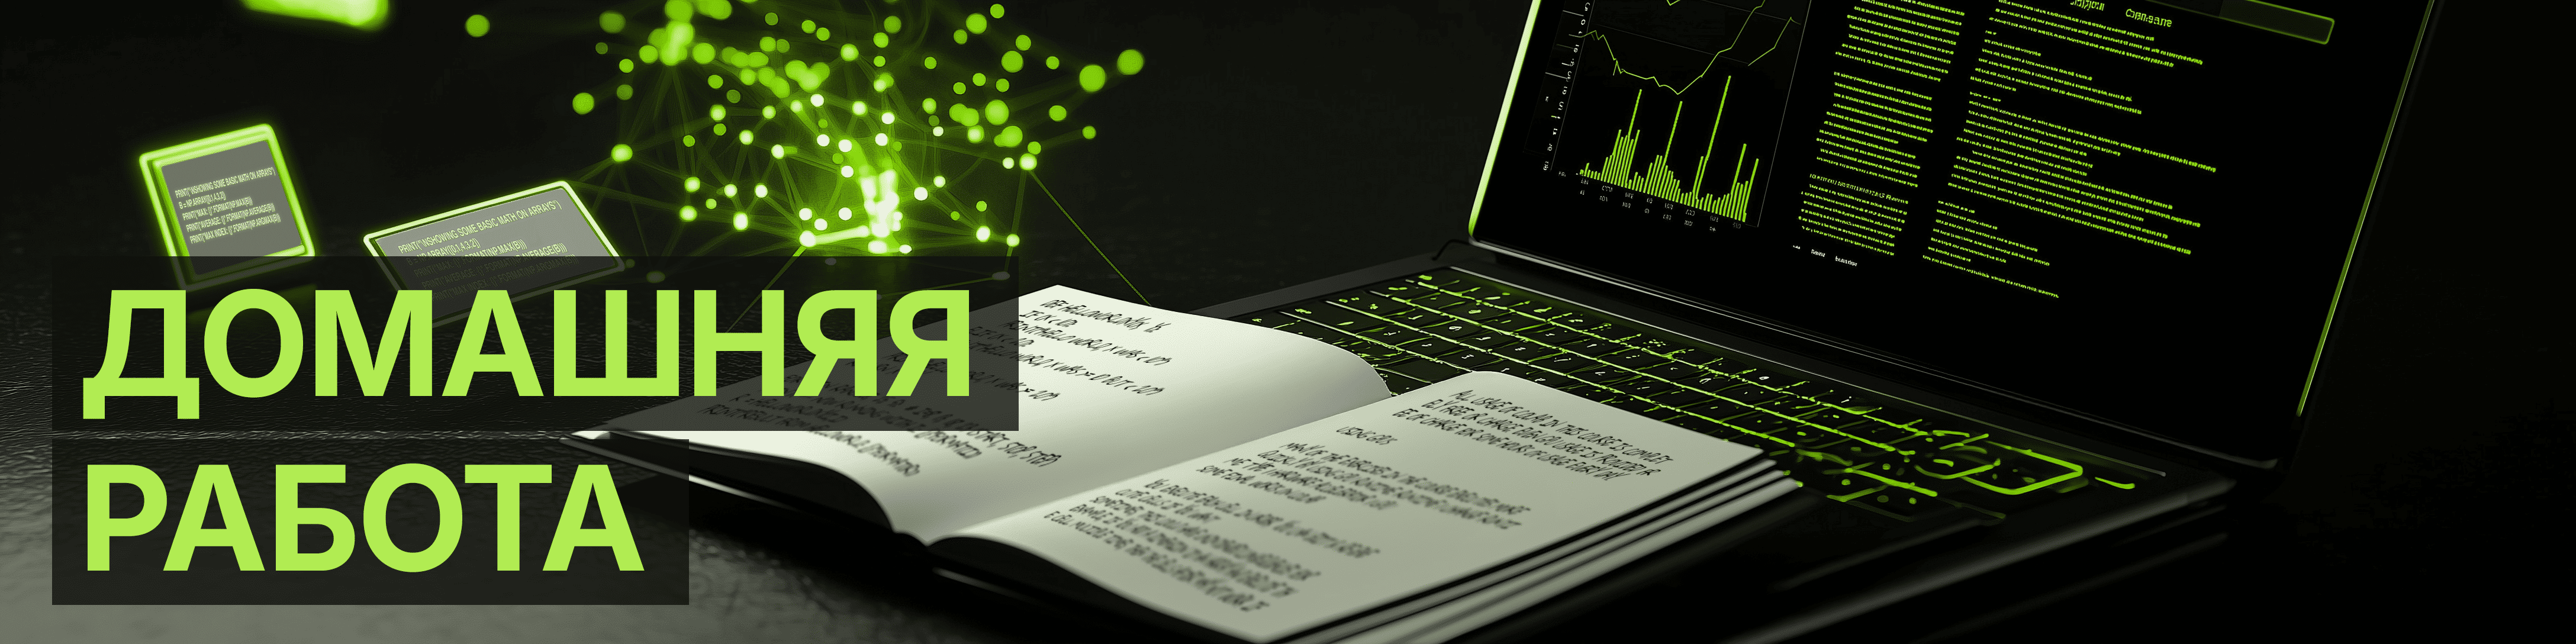

**Навигация по уроку**
1. [Задача обнаружения объектов](https://colab.research.google.com/drive/1oOrMEXL1LeMmbnu0wxnSjXMOeQaUthI4)
2. [Обнаружение объектов. Архитектура YOLOv3](https://colab.research.google.com/drive/112try2PtPk-jYcyeo61y5hsdmY9brrzD)
3. [Детекция в реальном времени. YOLOv11](https://colab.research.google.com/drive/1R1o-wD4jRT0DXhKbeWL0yVzV4JFhXTHq)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Используя датасет [Traffic Signs Detection](https://storage.yandexcloud.net/academy.ai/CV/traffic_signs_detection.zip), дообучите модель YOLO v11 распознавать дорожные знаки в дорожном траффике.
2. Используйте видео, которое находится также внутри датасета для проверки модели.

**Задание 2. На 4 балла:**

1. Используйте модель YOLOv3 из урока, а также вспомогательные функции урока, обучите модель детектировать шахматные фигуры. Модель создайте с нуля.
  

**Задание 3. На 5 балла:**

1. Используйте модель YOLOv3 из урока, а также вспомогательные функции урока, обучите модель детектировать шахматные фигуры.  Модель создайте с нуля.
2. Обеспечьте, чтобы изображения на выходе сети восстанавливались до своего первоначального размера, при этом необходимо, чтобы размер предсказанных ограничивающих рамок, так же правильно трансформировался под размер изображения.
3. Продемонстрируйте работу сети на изображениях разного размера, как альбомной, так и портретной ориентации.

In [ ]:
import os
import requests
import zipfile
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, LeakyReLU, Add, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# --- 0. Константы и конфигурация ---
CHESS_YOLO_DIR = 'chess_yolo'
CHESS_YOLO_ZIP = 'chess_yolo.zip'
INPUT_SIZE = 416 # Стандартный размер входа для YOLOv3
NUM_ANCHORS_PER_SCALE = 3 # YOLOv3 использует 3 якоря на каждом из 3 масштабов

# Гиперпараметры для якорей
ANCHORS = np.array([
    [116,90], [156,198], [373,326], # Якоря для Stride 32 (самые крупные объекты)
    [30,61],  [62,45],  [59,119],  # Якоря для Stride 16 (средние объекты)
    [10,13],  [16,30],  [33,23]    # Якоря для Stride 8 (самые мелкие объекты)
]) / INPUT_SIZE # Нормализуем якоря по входному размеру

# Масштабы выходных сеток YOLO (Stride)
# Соответствуют порядку выходов модели: [output_stride_32, output_stride_16, output_stride_8]
STRIDES = [32, 16, 8]

# Коэффициенты потерь
LAMBDA_COORD = 1.0 # Коэффициент для потерь координат
LAMBDA_NO_OBJ = 0.5 # Коэффициент для потерь "нет объекта"

# Флаг для отладочных сообщений
DEBUG_MODE = True

In [ ]:
# --- 1. Загрузка и подготовка данных ---
def download_and_extract_data():
    if not os.path.exists(CHESS_YOLO_DIR):
        print(f"Скачиваем и распаковываем {CHESS_YOLO_ZIP}...")
        try:
            r = requests.get('https://storage.yandexcloud.net/academy.ai/CV/chess_yolo.zip', allow_redirects=True)
            r.raise_for_status() # Проверка на ошибки HTTP
            with open(CHESS_YOLO_ZIP, 'wb') as f: f.write(r.content)
            with zipfile.ZipFile(CHESS_YOLO_ZIP, 'r') as zip_ref: zip_ref.extractall('.')
            os.remove(CHESS_YOLO_ZIP)
            print("Скачивание и распаковка завершены.")
        except requests.exceptions.RequestException as e:
            print(f"ОШИБКА HTTP при скачивании данных: {e}")
            exit()
        except zipfile.BadZipFile as e:
            print(f"ОШИБКА: Загруженный файл '{CHESS_YOLO_ZIP}' поврежден: {e}")
            exit()
        except Exception as e:
            print(f"ОШИБКА во время подготовки данных: {e}")
            exit()
    else:
        print(f"Набор данных '{CHESS_YOLO_DIR}' уже существует.")

def load_annotations(dataset_path):
    annotations_df = pd.read_csv(os.path.join(dataset_path, '_annotations.csv'))
    return annotations_df

In [ ]:
# --- 2. Предварительная обработка изображений и аннотаций ---
def preprocess_image_and_boxes(image_path, annotations_for_image, input_size=INPUT_SIZE):
    """
    Изменяет размер изображения с сохранением соотношения сторон и масштабирует bounding boxes.
    Возвращает подготовленное изображение, нормализованные boxes в формате YOLO,
    и информацию для обратного преобразования.
    """
    image = cv2.imread(image_path)
    if image is None:
        if DEBUG_MODE: print(f"DEBUG: Изображение не найдено: {image_path}. Пропуск.")
        # Возвращаем None, чтобы вызывающая функция могла обработать ошибку
        return None, np.array([]), (0, 0), (0, 0, 0)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # YOLO обычно работает с RGB

    original_h, original_w = image.shape[:2]
    if DEBUG_MODE: print(f"DEBUG: preprocess: Оригинальные размеры изображения: {original_w}x{original_h}")

    # Вычисляем масштабирующий коэффициент
    scale = min(input_size / original_w, input_size / original_h)
    new_w, new_h = int(original_w * scale), int(original_h * scale)
    if DEBUG_MODE: print(f"DEBUG: preprocess: Новый размер (после масштабирования): {new_w}x{new_h}, Масштаб: {scale:.2f}")


    # Изменение размера изображения
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Вычисляем паддинг
    pad_w, pad_h = (input_size - new_w) // 2, (input_size - new_h) // 2
    if DEBUG_MODE: print(f"DEBUG: preprocess: Паддинг: w={pad_w}, h={pad_h}")

    # Добавление паддинга (серого цвета)
    padded_image = np.full((input_size, input_size, 3), 128, dtype=np.uint8)
    padded_image[pad_h:new_h + pad_h, pad_w:new_w + pad_w, :] = resized_image

    # Нормализация изображения [0, 1]
    padded_image = padded_image / 255.0
    if DEBUG_MODE: print(f"DEBUG: preprocess: Размер padded_image: {padded_image.shape}, min/max: {padded_image.min():.2f}/{padded_image.max():.2f}")


    transformed_boxes = []
    if not annotations_for_image.empty:
        for idx, row in annotations_for_image.iterrows():
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

            # Масштабирование координат
            xmin_scaled = (xmin * scale) + pad_w
            ymin_scaled = (ymin * scale) + pad_h
            xmax_scaled = (xmax * scale) + pad_w
            ymax_scaled = (ymax * scale) + pad_h

            # Преобразование к формату YOLO (center_x, center_y, width, height) и нормализация [0, 1]
            center_x = (xmin_scaled + xmax_scaled) / 2.0 / input_size
            center_y = (ymin_scaled + ymax_scaled) / 2.0 / input_size
            box_w = (xmax_scaled - xmin_scaled) / input_size
            box_h = (ymax_scaled - ymin_scaled) / input_size

            # Игнорировать рамки с нулевой шириной или высотой, так как они могут вызвать проблемы с логарифмом в loss
            if box_w <= 0 or box_h <= 0:
                if DEBUG_MODE: print(f"DEBUG: preprocess: Пропуск GT-рамки с нулевой шириной/высотой: w={box_w:.4f}, h={box_h:.4f}")
                continue

            class_id = classes.index(row['class'])
            if DEBUG_MODE and idx == 0: # Только для первой рамки для отладки
                print(f"DEBUG: preprocess: Первая GT-рамка: original=[{row['xmin']},{row['ymin']},{row['xmax']},{row['ymax']}], normalized_yolo=[{center_x:.4f},{center_y:.4f},{box_w:.4f},{box_h:.4f}], class={row['class']}")

            transformed_boxes.append([center_x, center_y, box_w, box_h, class_id])

    return padded_image, np.array(transformed_boxes), (original_w, original_h), (pad_w, pad_h, scale)

def postprocess_boxes(boxes, original_dims, padding_info, input_size=INPUT_SIZE):
    """
    Преобразует предсказанные нормализованные bounding boxes обратно в оригинальные пиксельные координаты.
    boxes: numpy array, [xmin_norm, ymin_norm, xmax_norm, ymax_norm, conf, class_id]
           (после decode_yolo_output и NMS, нормализованные к INPUT_SIZE)
    original_dims: (original_w, original_h)
    padding_info: (pad_w, pad_h, scale) из preprocess_image_and_boxes
    """
    if boxes.size == 0:
        if DEBUG_MODE: print("DEBUG: postprocess: Нет рамок для постобработки.")
        return np.array([])

    original_w, original_h = original_dims
    pad_w, pad_h, scale = padding_info

    if DEBUG_MODE: print(f"DEBUG: postprocess: Обработка {len(boxes)} рамок.")

    post_processed_boxes = []
    for box_idx, box in enumerate(boxes):
        # Нормализованные предсказания YOLO (xmin, ymin, xmax, ymax)
        xmin_norm, ymin_norm, xmax_norm, ymax_norm, conf, class_id = box

        # Денормализация к размеру INPUT_SIZE
        xmin_scaled = xmin_norm * input_size
        ymin_scaled = ymin_norm * input_size
        xmax_scaled = xmax_norm * input_size
        ymax_scaled = ymax_norm * input_size

        # Удаление паддинга
        xmin_unpadded = xmin_scaled - pad_w
        ymin_unpadded = ymin_scaled - pad_h
        xmax_unpadded = xmax_scaled - pad_w
        ymax_unpadded = ymax_scaled - pad_h

        # Демасштабирование к исходному размеру
        xmin = xmin_unpadded / scale
        ymin = ymin_unpadded / scale
        xmax = xmax_unpadded / scale
        ymax = ymax_unpadded / scale

        # Обрезание координат до границ изображения
        xmin = max(0, int(xmin))
        ymin = max(0, int(ymin))
        xmax = min(original_w, int(xmax))
        ymax = min(original_h, int(ymax))

        post_processed_boxes.append([xmin, ymin, xmax, ymax, conf, class_id])
        if DEBUG_MODE and box_idx == 0: # Только для первой постобработанной рамки
            print(f"DEBUG: postprocess: Первая рамка после постобработки: [{xmin},{ymin},{xmax},{ymax}], conf={conf:.2f}, class={int(class_id)}")

    return np.array(post_processed_boxes)

# --- Вспомогательные функции для IoU и преобразования рамок ---
def bbox_iou(boxes1, boxes2):
    """
    Calculates the Intersection over Union (IoU) between two sets of bounding boxes.
    Boxes should be in format [x_center, y_center, width, height] (normalized).
    """
    # Convert to [xmin, ymin, xmax, ymax]
    boxes1_xyxy = np.concatenate([boxes1[..., :2] - boxes1[..., 2:4] / 2,
                                  boxes1[..., :2] + boxes1[..., 2:4] / 2], axis=-1)
    boxes2_xyxy = np.concatenate([boxes2[..., :2] - boxes2[..., 2:4] / 2,
                                  boxes2[..., :2] + boxes2[..., 2:4] / 2], axis=-1)

    # Calculate intersection area
    intersect_xmin = np.maximum(boxes1_xyxy[..., 0], boxes2_xyxy[..., 0])
    intersect_ymin = np.maximum(boxes1_xyxy[..., 1], boxes2_xyxy[..., 1])
    intersect_xmax = np.minimum(boxes1_xyxy[..., 2], boxes2_xyxy[..., 2])
    intersect_ymax = np.minimum(boxes1_xyxy[..., 3], boxes2_xyxy[..., 3])

    intersect_width = np.maximum(0, intersect_xmax - intersect_xmin)
    intersect_height = np.maximum(0, intersect_ymax - intersect_ymin)
    intersect_area = intersect_width * intersect_height

    # Calculate union area
    boxes1_area = boxes1[..., 2] * boxes1[..., 3]
    boxes2_area = boxes2[..., 2] * boxes2[..., 3]
    union_area = boxes1_area + boxes2_area - intersect_area

    # Avoid division by zero
    iou = np.where(union_area == 0, 0, intersect_area / union_area)
    return iou

# --- Функция для формирования целевых тензоров YOLOv3 (Ground Truth) ---
def make_yolo_targets(gt_boxes, anchors, strides, num_classes, input_size=INPUT_SIZE):
    """
    Создает целевые тензоры для каждого выходного масштаба YOLO.
    gt_boxes: numpy array, shape (num_gt_boxes, 5), format [center_x, center_y, width, height, class_id] (normalized to INPUT_SIZE)
    anchors: numpy array, shape (9, 2), all 9 anchors (normalized to INPUT_SIZE)
    strides: list, e.g., [32, 16, 8]
    num_classes: int
    """
    num_scales = len(strides)

    # Инициализация целевых тензоров для каждого масштаба
    # y_true_shape = (grid_h, grid_w, num_anchors_per_scale, 5 + num_classes)
    y_true = [np.zeros((input_size // s, input_size // s, NUM_ANCHORS_PER_SCALE, 5 + num_classes), dtype=np.float32)
              for s in strides]

    # Маски для отслеживания, какой якорь назначен какому объекту
    # (для функции потерь, чтобы знать, какие предсказания сравнивать с ground truth)
    # anchor_masks: [0,1,2] for stride 32, [3,4,5] for stride 16, [6,7,8] for stride 8
    anchor_indices_per_scale = [
        np.array([0,1,2]), # For stride 32 (largest anchors)
        np.array([3,4,5]), # For stride 16 (medium anchors)
        np.array([6,7,8])  # For stride 8 (smallest anchors)
    ]

    # Если нет объектов на изображении, возвращаем пустые целевые тензоры
    if gt_boxes.size == 0:
        if DEBUG_MODE: print("DEBUG: make_yolo_targets: Нет GT-рамок на изображении. Возвращаем пустые таргеты.")
        return y_true

    if DEBUG_MODE: print(f"DEBUG: make_yolo_targets: Обработка {len(gt_boxes)} GT-рамок.")

    # Итерация по каждому ground truth объекту
    for gt_box_idx, gt_box in enumerate(gt_boxes):
        gt_xc, gt_yc, gt_w, gt_h, gt_class_id = gt_box

        # Создаем массив для сравнения с якорями: [0, 0, gt_w, gt_h]
        # IoU должно быть независимым от положения, только от размеров
        gt_box_for_iou = np.array([0, 0, gt_w, gt_h])

        # Вычисляем IoU истинной рамки со всеми 9 якорями
        # anchors_for_iou: [0, 0, anchor_w, anchor_h]
        ious = bbox_iou(np.expand_dims(gt_box_for_iou, 0),
                        np.concatenate([np.zeros_like(anchors), anchors], axis=-1))

        # Находим якорь с наибольшим IoU
        best_anchor_idx = np.argmax(ious)
        best_iou = ious[best_anchor_idx]

        # Определяем, к какому масштабу принадлежит этот якорь
        scale_idx = -1
        for i, anchor_mask in enumerate(anchor_indices_per_scale):
            if best_anchor_idx in anchor_mask:
                scale_idx = i
                break

        if scale_idx == -1: # Этого не должно произойти, если якоря правильно сопоставлены
            if DEBUG_MODE: print(f"DEBUG: make_yolo_targets: Ошибка: Якорь {best_anchor_idx} не найден ни в одном масштабе. Пропуск GT-рамки.")
            continue

        # Получаем размер сетки для этого масштаба
        grid_size = input_size // strides[scale_idx]

        # Вычисляем координаты центра объекта в масштабе сетки
        grid_xc, grid_yc = gt_xc * grid_size, gt_yc * grid_size

        # Определяем координаты ячейки сетки (целочисленные)
        j = int(np.floor(grid_xc)) # col index
        i = int(np.floor(grid_yc)) # row index

        # Обрезаем координаты, чтобы они не выходили за пределы сетки
        j = np.clip(j, 0, grid_size - 1)
        i = np.clip(i, 0, grid_size - 1)


        # Вычисляем относительные координаты центра внутри ячейки сетки (tx, ty)
        # Эти значения будут предсказываться моделью после сигмоиды
        tx = grid_xc - j
        ty = grid_yc - i

        # Получаем размеры выбранного якоря для текущего масштаба (нормализованные к INPUT_SIZE)
        best_anchor_w, best_anchor_h = anchors[best_anchor_idx]

        # Вычисляем относительные ширину и высоту (tw, th)
        # Эти значения будут предсказываться моделью (raw_wh), а затем экспоненциироваться и умножаться на якорь
        # tw = log(gt_w / anchor_w)
        # th = log(gt_h / anchor_h)
        # tf.clip_by_value, чтобы избежать log(0) или log(отрицательного числа) если gt_w или gt_h слишком малы
        tw = np.log(np.maximum(gt_w / best_anchor_w, 1e-9))
        th = np.log(np.maximum(gt_h / best_anchor_h, 1e-9))

        # Определяем индекс якоря внутри его масштаба (0, 1 или 2)
        local_anchor_idx = list(anchor_indices_per_scale[scale_idx]).index(best_anchor_idx)

        # Заполняем целевой тензор
        # Формат: [tx, ty, tw, th, objectness (1), class_probs (one-hot)]

        # Устанавливаем confident score (objectness) в 1.0
        y_true[scale_idx][i, j, local_anchor_idx, 4] = 1.0

        # Устанавливаем координаты и размеры
        y_true[scale_idx][i, j, local_anchor_idx, 0:2] = [tx, ty]
        y_true[scale_idx][i, j, local_anchor_idx, 2:4] = [tw, th]

        # Устанавливаем one-hot вектор класса
        y_true[scale_idx][i, j, local_anchor_idx, 5 + int(gt_class_id)] = 1.0

        if DEBUG_MODE and gt_box_idx == 0: # Только для первой GT-рамки
            print(f"DEBUG: make_yolo_targets: GT-рамка {gt_box_idx}: scale_idx={scale_idx}, grid_size={grid_size}, cell=({i},{j}), local_anchor_idx={local_anchor_idx}")
            print(f"  GT (norm): xc={gt_xc:.4f}, yc={gt_yc:.4f}, w={gt_w:.4f}, h={gt_h:.4f}")
            print(f"  Best anchor (norm): w={best_anchor_w:.4f}, h={best_anchor_h:.4f}, IoU={best_iou:.4f}")
            print(f"  Target tx, ty: {tx:.4f}, {ty:.4f}. Target tw, th: {tw:.4f}, {th:.4f}")

    return y_true

In [ ]:
# --- 3. Архитектура модели YOLOv3 ---
def _conv_block(inputs, filters, kernel_size, strides, padding='same', use_bn=True, activation='leaky'):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=not use_bn)(inputs)
    if use_bn:
        x = BatchNormalization()(x)
    if activation == 'leaky':
        x = LeakyReLU(negative_slope=0.1)(x)
    elif activation == 'linear':
        pass
    return x

def _residual_block(inputs, filters):
    prev = inputs
    x = _conv_block(inputs, filters // 2, 1, 1)
    x = _conv_block(x, filters, 3, 1)
    x = Add()([prev, x])
    return x

def _darknet_53(inputs):
    x = _conv_block(inputs, 32, 3, 1)
    x = _conv_block(x, 64, 3, 2)
    for _ in range(1):
        x = _residual_block(x, 64)

    x = _conv_block(x, 128, 3, 2)
    for _ in range(2):
        x = _residual_block(x, 128)

    x = _conv_block(x, 256, 3, 2)
    for _ in range(8):
        x = _residual_block(x, 256)
    feature_map_stride_8 = x

    x = _conv_block(x, 512, 3, 2)
    for _ in range(8):
        x = _residual_block(x, 512)
    feature_map_stride_16 = x

    x = _conv_block(x, 1024, 3, 2)
    for _ in range(4):
        x = _residual_block(x, 1024)
    feature_map_stride_32 = x

    return feature_map_stride_8, feature_map_stride_16, feature_map_stride_32

def create_yolov3_model(input_shape=(INPUT_SIZE, INPUT_SIZE, 3), num_classes=80):
    inputs = tf.keras.Input(shape=input_shape)
    feature_map_stride_8, feature_map_stride_16, feature_map_stride_32 = _darknet_53(inputs)

    x = _conv_block(feature_map_stride_32, 512, 1, 1)
    x = _conv_block(x, 1024, 3, 1)
    x = _conv_block(x, 512, 1, 1)
    x = _conv_block(x, 1024, 3, 1)
    x = _conv_block(x, 512, 1, 1)
    output_stride_32_feature = x

    output_1 = _conv_block(output_stride_32_feature, 1024, 3, 1)
    output_1 = Conv2D(NUM_ANCHORS_PER_SCALE * (5 + num_classes), 1, 1, activation='linear')(output_1)

    x = _conv_block(output_stride_32_feature, 256, 1, 1)
    x = UpSampling2D(2)(x)
    x = Concatenate()([x, feature_map_stride_16])

    x = _conv_block(x, 256, 1, 1)
    x = _conv_block(x, 512, 3, 1)
    x = _conv_block(x, 256, 1, 1)
    x = _conv_block(x, 512, 3, 1)
    x = _conv_block(x, 256, 1, 1)
    output_stride_16_feature = x

    output_2 = _conv_block(output_stride_16_feature, 512, 3, 1)
    output_2 = Conv2D(NUM_ANCHORS_PER_SCALE * (5 + num_classes), 1, 1, activation='linear')(output_2)

    x = _conv_block(output_stride_16_feature, 128, 1, 1)
    x = UpSampling2D(2)(x)
    x = Concatenate()([x, feature_map_stride_8])

    x = _conv_block(x, 128, 1, 1)
    x = _conv_block(x, 256, 3, 1)
    x = _conv_block(x, 128, 1, 1)
    x = _conv_block(x, 256, 3, 1)
    x = _conv_block(x, 128, 1, 1)

    output_3 = _conv_block(x, 256, 3, 1)
    output_3 = Conv2D(NUM_ANCHORS_PER_SCALE * (5 + num_classes), 1, 1, activation='linear')(output_3)

    model = Model(inputs, [output_1, output_2, output_3])
    return model

In [ ]:
# --- 4. Функция потерь и оптимизатор ---
# Обновленная функция потерь YOLOv3
def yolo_loss(y_true_list, y_pred_list, anchors=ANCHORS, strides=STRIDES, num_classes=None):
    total_loss = 0
    # Создаем кросс-энтропию для удобства
    bce = tf.keras.losses.BinaryCrossentropy(reduction='none')

    # Якоря для каждого масштаба
    anchor_indices_per_scale = [
        np.array([0,1,2]), # For stride 32 (largest anchors)
        np.array([3,4,5]), # For stride 16 (medium anchors)
        np.array([6,7,8])  # For stride 8 (smallest anchors)
    ]

    for i, (y_true, y_pred) in enumerate(zip(y_true_list, y_pred_list)):
        # Размеры сетки
        grid_h, grid_w = tf.shape(y_pred)[1], tf.shape(y_pred)[2]

        # Получаем "сырые" (raw) предсказания и преобразуем их
        y_pred = tf.reshape(y_pred, (-1, grid_h, grid_w, NUM_ANCHORS_PER_SCALE, 5 + num_classes))

        pred_raw_xy = y_pred[..., 0:2]
        pred_raw_wh = y_pred[..., 2:4]
        pred_obj_conf_logits = y_pred[..., 4:5]
        pred_class_logits = y_pred[..., 5:]

        # Применяем сигмоиду для xy, objectness и class probabilities
        pred_xy = tf.sigmoid(pred_raw_xy)
        pred_obj_conf = tf.sigmoid(pred_obj_conf_logits)
        pred_class_probs = tf.sigmoid(pred_class_logits)

        # Извлекаем истинные значения из y_true
        true_xy = y_true[..., 0:2]
        true_wh = y_true[..., 2:4] # log(gt_w / anchor_w), log(gt_h / anchor_h)
        true_obj_mask = y_true[..., 4:5] # 1 if object, 0 if no object
        true_class_probs = y_true[..., 5:]

        # 1. Loss для координат (xy, wh)
        # Применяется только там, где есть объект (true_obj_mask == 1)

        # Для xy (BCE, так как это относительные координаты внутри ячейки [0,1])
        xy_loss = true_obj_mask * tf.expand_dims(bce(true_xy, pred_xy), axis=-1)
        xy_loss = tf.reduce_sum(xy_loss)

        # Для wh (MSE, так как это log-масштабированные смещения)
        wh_loss = true_obj_mask * tf.square(true_wh - pred_raw_wh) # Используем raw_wh для MSE
        wh_loss = tf.reduce_sum(wh_loss)

        # 2. Loss для уверенности (objectness)
        # a) Loss для "есть объект"
        obj_loss = true_obj_mask * tf.expand_dims(bce(true_obj_mask, pred_obj_conf), axis=-1)
        obj_loss = tf.reduce_sum(obj_loss)

        # b) Loss для "нет объекта" (no_obj_loss)
        no_obj_mask = (1 - true_obj_mask)
        no_obj_loss = LAMBDA_NO_OBJ * no_obj_mask * tf.expand_dims(bce(true_obj_mask, pred_obj_conf), axis=-1)
        no_obj_loss = tf.reduce_sum(no_obj_loss)

        # 3. Loss для классификации
        # Применяется только там, где есть объект (true_obj_mask == 1)
        class_loss = true_obj_mask * tf.expand_dims(bce(true_class_probs, pred_class_probs), axis=-1)
        class_loss = tf.reduce_sum(class_loss)

        # Суммируем все компоненты потерь
        scale_loss = LAMBDA_COORD * (xy_loss + wh_loss) + obj_loss + no_obj_loss + class_loss
        total_loss += scale_loss

        if DEBUG_MODE:

            tf.print("DEBUG: yolo_loss: Scale", i, "(stride=", strides[i], ") - ")
            tf.print("  xy_loss:", xy_loss, ", wh_loss:", wh_loss)
            tf.print("  obj_loss:", obj_loss, ", no_obj_loss:", no_obj_loss)
            tf.print("  class_loss:", class_loss, ", Total scale loss:", scale_loss)

    if DEBUG_MODE:

        tf.print("DEBUG: yolo_loss: Общая потеря батча:", total_loss)
    return total_loss

optimizer = Adam(learning_rate=1e-4) # Уменьшим learning rate для стабильности

In [ ]:
# --- 5. ФУНКЦИОНАЛЬНЫЙ ЦИКЛ ОБУЧЕНИЯ ---
@tf.function
def train_step(model, images, y_true_list, optimizer, anchors, strides, num_classes):
    with tf.GradientTape() as tape:
        y_pred_list = model(images, training=True)
        loss_value = yolo_loss(y_true_list, y_pred_list, anchors, strides, num_classes)

    gradients = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))


    if DEBUG_MODE: tf.print("DEBUG: train_step: Loss value for current step:", loss_value)
    return loss_value

def train_model(model, train_image_filenames, train_annotations_df, classes, anchors, strides, epochs=50, batch_size=4):
    print("--- Начинаем ФУНКЦИОНАЛЬНЫЙ цикл обучения ---")

    num_classes = len(classes)

    # Рассчитываем размеры сетки для каждого масштаба
    grid_sizes = [INPUT_SIZE // stride for stride in strides]

    output_types = (tf.float32, (tf.float32, tf.float32, tf.float32))
    output_shapes = (
        tf.TensorShape([None, INPUT_SIZE, INPUT_SIZE, 3]),
        (tf.TensorShape([None, grid_sizes[0], grid_sizes[0], NUM_ANCHORS_PER_SCALE, 5 + num_classes]), # Для первого масштаба (stride 32 -> grid 13x13)
         tf.TensorShape([None, grid_sizes[1], grid_sizes[1], NUM_ANCHORS_PER_SCALE, 5 + num_classes]), # Для второго масштаба (stride 16 -> grid 26x26)
         tf.TensorShape([None, grid_sizes[2], grid_sizes[2], NUM_ANCHORS_PER_SCALE, 5 + num_classes]))  # Для третьего масштаба (stride 8 -> grid 52x52)
    )

    # Важно: generator function должна быть передана без вызова
    train_dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(
            train_image_filenames,
            train_annotations_df,
            classes,
            anchors,
            strides,
            batch_size=batch_size,
            dataset_path=os.path.join(CHESS_YOLO_DIR, 'train'),
            input_size=INPUT_SIZE
        ),
        output_types=output_types,
        output_shapes=output_shapes
    )

    # Используем .prefetch для повышения производительности
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

    steps_per_epoch = max(1, (len(train_image_filenames) + batch_size - 1) // batch_size) # Правильный расчет шагов
    if DEBUG_MODE: print(f"DEBUG: train_model: Ожидаемое количество шагов за эпоху: {steps_per_epoch}")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        total_loss = 0
        for step, (batch_images, batch_y_true) in enumerate(train_dataset):
            if step >= steps_per_epoch: # Останавливаем, если достигли конца эпохи
                if DEBUG_MODE: print(f"DEBUG: train_model: Достигнуто {steps_per_epoch} шагов, прерываем эпоху.")
                break

            loss_value = train_step(model, batch_images, batch_y_true, optimizer, anchors, strides, num_classes)
            total_loss += loss_value

            if (step + 1) % 10 == 0 or (step + 1) == steps_per_epoch:
                avg_loss_so_far = total_loss / (step + 1)
                print(f"   Step {step+1}/{steps_per_epoch}, Loss: {avg_loss_so_far.numpy():.4f}")

        avg_epoch_loss = total_loss / steps_per_epoch
        print(f"Epoch {epoch+1} finished, Average Loss: {avg_epoch_loss.numpy():.4f}")

    print("\nОбучение завершено.")
    # Сохранение весов модели
    model.save_weights('yolov3_chess_weights.weights.h5') # ИСПРАВЛЕНО ИМЯ ФАЙЛА ???
    print("Веса модели сохранены в 'yolov3_chess_weights.weights.h5'")
    return model

In [ ]:
# --- 6. Постобработка предсказаний ---

def decode_yolo_output(yolo_output, anchors_for_scale, input_size, num_classes_inferred, conf_threshold=0.5):
    try:
        batch_size = tf.shape(yolo_output)[0]
        grid_h = tf.shape(yolo_output)[1]
        grid_w = tf.shape(yolo_output)[2]

        if grid_h <= 0 or grid_w <= 0:
            tf.print(f"ERROR: decode_yolo_output: Invalid grid dimensions: {grid_h}x{grid_w}")
            return tf.constant([], shape=(0,0,0), dtype=tf.float32) # Возвращаем пустой тензор

        expected_last_dim_for_reshape = NUM_ANCHORS_PER_SCALE * (5 + num_classes_inferred)
        if tf.shape(yolo_output)[-1] != expected_last_dim_for_reshape:
            tf.print(f"ERROR: decode_yolo_output: Несоответствие последней размерности yolo_output для изменения формы. Ожидается {expected_last_dim_for_reshape}, получено {tf.shape(yolo_output)[-1]}.")
            return tf.constant([], shape=(batch_size, 0, expected_last_dim_for_reshape), dtype=tf.float32)


        predictions = tf.reshape(yolo_output, (batch_size, grid_h, grid_w, NUM_ANCHORS_PER_SCALE, 5 + num_classes_inferred))

        expected_last_dim = 5 + num_classes_inferred
        if tf.shape(predictions)[-1] != expected_last_dim:
            tf.print(f"ERROR: decode_yolo_output: Unexpected last dimension in predictions: {tf.shape(predictions)[-1]}, expected {expected_last_dim}")
            return tf.constant([], shape=(batch_size, 0, expected_last_dim), dtype=tf.float32)

        raw_xy = predictions[..., 0:2]
        raw_wh = predictions[..., 2:4]
        obj_conf_logits = predictions[..., 4:5]
        class_logits = predictions[..., 5:]

        obj_conf = tf.sigmoid(obj_conf_logits)
        class_probs = tf.sigmoid(class_logits)

        grid_x = tf.range(tf.cast(grid_w, tf.float32))
        grid_y = tf.range(tf.cast(grid_h, tf.float32))
        grid_x, grid_y = tf.meshgrid(grid_x, grid_y)
        grid = tf.expand_dims(tf.stack([grid_x, grid_y], axis=-1), axis=2)
        grid_replicated = tf.tile(tf.expand_dims(grid, 0), [batch_size, 1, 1, NUM_ANCHORS_PER_SCALE, 1])


        box_xy = (tf.sigmoid(raw_xy) + grid_replicated) / tf.stack([tf.cast(grid_w, tf.float32), tf.cast(grid_h, tf.float32)])

        # anchors_for_scale - это numpy массив, поэтому tf.constant здесь подходит
        anchors_tensor = tf.constant(anchors_for_scale, dtype=tf.float32)
        if tf.shape(anchors_tensor)[0] != NUM_ANCHORS_PER_SCALE or tf.shape(anchors_tensor)[1] != 2:
            tf.print(f"ERROR: decode_yolo_output: Invalid shape for anchors_for_scale: {tf.shape(anchors_tensor)}")
            return tf.constant([], shape=(batch_size, 0, expected_last_dim), dtype=tf.float32)

        anchors_tensor = tf.reshape(anchors_tensor, (1, 1, 1, NUM_ANCHORS_PER_SCALE, 2))


        box_wh = tf.exp(raw_wh) * anchors_tensor / tf.stack([tf.cast(input_size, tf.float32), tf.cast(input_size, tf.float32)])

        box_xmin = box_xy[..., 0:1] - box_wh[..., 0:1] / 2
        box_ymin = box_xy[..., 1:2] - box_wh[..., 1:2] / 2
        box_xmax = box_xy[..., 0:1] + box_wh[..., 0:1] / 2
        box_ymax = box_xy[..., 1:2] + box_wh[..., 1:2] / 2

        boxes_and_probs = tf.concat([box_xmin, box_ymin, box_xmax, box_ymax, obj_conf, class_probs], axis=-1)

        try:
            boxes_and_probs = tf.reshape(boxes_and_probs, (batch_size, -1, 5 + num_classes_inferred))
        except tf.errors.InvalidArgumentError as e:
            tf.print(f"ERROR: decode_yolo_output: Failed to reshape boxes_and_probs: {e}")
            return tf.constant([], shape=(batch_size, 0, expected_last_dim), dtype=tf.float32)

        return boxes_and_probs
    except Exception as e:
        tf.print(f"ERROR: decode_yolo_output failed: {e}")
        return tf.constant([], shape=(0,0,0), dtype=tf.float32)

def non_max_suppression(boxes_input, scores_input, iou_threshold=0.5):
    """
    Применяет Non-Maximum Suppression (NMS) для устранения дублирующихся рамок.
    boxes_input: tf.Tensor, ожидается формат [xmin, ymin, xmax, ymax] (нормализованные)
    scores_input: tf.Tensor, оценки уверенности для каждой рамки.
    Возвращает: tf.Tensor выбранных рамок в формате [xmin, ymin, xmax, ymax, confidence, class_id].
    """
    # Убедимся, что входные данные - это тензоры TensorFlow и имеют тип float32
    boxes = tf.convert_to_tensor(boxes_input, dtype=tf.float32)
    scores = tf.convert_to_tensor(scores_input, dtype=tf.float32)

    # Обработка случая, когда нет рамок
    if tf.size(boxes) == 0:
        if DEBUG_MODE: tf.print("DEBUG: NMS: Нет рамок для применения NMS.")
        # Важно вернуть пустой тензор с правильной формой и типом данных
        return tf.constant([], shape=(0, 6), dtype=tf.float32)

    if DEBUG_MODE: tf.print(f"DEBUG: NMS: Рамок до NMS:", tf.shape(boxes)[0])

    # Извлекаем координаты рамок, оценки уверенности и ID классов
    # Для tf.image.non_max_suppression формат рамок должен быть [ymin, xmin, ymax, xmax]
    # Текущий формат: [xmin, ymin, xmax, ymax]
    boxes_tf_format = tf.gather(boxes, tf.constant([1, 0, 3, 2], dtype=tf.int32), axis=1) # Преобразуем в [ymin, xmin, ymax, ymax]

    selected_indices = tf.image.non_max_suppression(
        boxes_tf_format, # Рамки в формате [ymin, xmin, ymax, xmax]
        scores,          # Скоры
        max_output_size=100, # Максимальное количество рамок после NMS
        iou_threshold=iou_threshold
    )

    if DEBUG_MODE: tf.print(f"DEBUG: NMS: Индексов после NMS:", tf.shape(selected_indices)[0])
    return selected_indices # Возвращаем индексы, как ожидается в visualize_detections


def visualize_detections(image_path, model, classes, anchors, conf_threshold=0.1, iou_threshold=0.3):
    """
    Визуализирует предсказанные ограничивающие рамки на изображении.
    Динамически определяет количество классов на основе вывода модели.
    """
    if DEBUG_MODE: tf.print("\nDEBUG: visualize_detections: Обработка изображения:", image_path)

    if not isinstance(image_path, str) or not image_path:
        print("ERROR: visualize_detections: image_path должен быть непустой строкой.")
        return

    if not hasattr(model, 'predict') or not callable(model.predict):
        print("ERROR: visualize_detections: 'model' должен быть объектом с методом 'predict'.")
        return

    if not isinstance(classes, (list, tuple)) or not classes:
        print("ERROR: visualize_detections: 'classes' должен быть непустым списком или кортежем.")
        return
    if not all(isinstance(c, str) for c in classes):
        print("ERROR: visualize_detections: Все элементы в 'classes' должны быть строками.")
        return

    if not isinstance(anchors, np.ndarray) or anchors.shape != (9, 2):
        print("ERROR: visualize_detections: 'anchors' должен быть numpy массивом формы (9, 2).")
        return

    if not isinstance(conf_threshold, (int, float)) or not (0.0 <= conf_threshold <= 1.0):
        print("ERROR: visualize_detections: 'conf_threshold' должен быть числом в диапазоне [0.0, 1.0].")
        return

    if not isinstance(iou_threshold, (int, float)) or not (0.0 <= iou_threshold <= 1.0):
        print("ERROR: visualize_detections: 'iou_threshold' должен быть числом в диапазоне [0.0, 1.0].")
        return

    dummy_annotations = pd.DataFrame(columns=['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class'])
    processed_image, gt_boxes_normalized, original_dims, pad_info = preprocess_image_and_boxes(
        image_path, dummy_annotations, INPUT_SIZE)

    if processed_image is None: # Обработка случая, когда preprocess_image_and_boxes вернул None
        return

    if tf.rank(processed_image) != 3 or tf.shape(processed_image)[-1] != 3:
        tf.print(f"ERROR: visualize_detections: processed_image имеет некорректный ранг или каналы: {tf.shape(processed_image)}")
        return
    if tf.reduce_any(tf.less_equal(tf.shape(processed_image), 0)):
        tf.print(f"ERROR: visualize_detections: processed_image имеет нулевые измерения: {tf.shape(processed_image)}")
        return

    input_image_for_model = tf.expand_dims(processed_image, axis=0)

    if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Shape of input_image_for_model before model.predict:", tf.shape(input_image_for_model))

    try:
        yolo_outputs = model.predict(input_image_for_model)
    except Exception as e:
        print(f"ERROR: visualize_detections: Ошибка при вызове model.predict: {e}")
        return

    # Убедимся, что yolo_outputs является списком, даже если модель вернула один тензор
    if not isinstance(yolo_outputs, list):
        if tf.is_tensor(yolo_outputs) and tf.rank(yolo_outputs) == 4:
            yolo_outputs = [yolo_outputs]
        else:
            tf.print(f"ERROR: visualize_detections: model.predict должен вернуть список тензоров или один 4D тензор, но получил {type(yolo_outputs)}.")
            return

    EXPECTED_NUM_SCALES = len(STRIDES) # Используем len(STRIDES) для определения ожидаемого количества масштабов
    if len(yolo_outputs) != EXPECTED_NUM_SCALES:
        tf.print(f"WARNING: visualize_detections: Количество выходов модели ({len(yolo_outputs)}) не соответствует ожидаемому количеству масштабов ({EXPECTED_NUM_SCALES}).")

    inferred_num_classes = None
    if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):")
    for idx, output_raw in enumerate(yolo_outputs):
        output = tf.convert_to_tensor(output_raw)

        if DEBUG_MODE:
            tf.print(f"DEBUG:   Output[{idx}] - is_tensor: {tf.is_tensor(output)}, rank: {tf.rank(output)}, shape[0]: {tf.shape(output)[0]}, shape[-1]: {tf.shape(output)[-1]}")

        if not tf.is_tensor(output) or tf.rank(output) != 4 or tf.shape(output)[0] != 1:
            tf.print(f"ERROR: Output[{idx}] имеет некорректную форму или ранг: {tf.shape(output)}. Ожидается (1, grid_h, grid_w, channels).")
            return

        output_channels = tf.shape(output)[-1]

        if output_channels % NUM_ANCHORS_PER_SCALE != 0:
            tf.print(f"ERROR: Output[{idx}] Последняя размерность ({output_channels}) не делится на NUM_ANCHORS_PER_SCALE ({NUM_ANCHORS_PER_SCALE}). Это указывает на некорректный формат вывода модели.")
            return

        elements_per_anchor = output_channels // NUM_ANCHORS_PER_SCALE
        if elements_per_anchor < 5:
            tf.print(f"ERROR: Output[{idx}] 'Элементов на якорь' ({elements_per_anchor}) меньше 5. Некорректный формат вывода.")
            return

        current_inferred_num_classes = elements_per_anchor - 5

        if inferred_num_classes is None:
            inferred_num_classes = current_inferred_num_classes
        elif inferred_num_classes != current_inferred_num_classes:
            tf.print(f"WARNING: visualize_detections: Несоответствие количества классов между выходами модели. Ранее {inferred_num_classes}, сейчас {current_inferred_num_classes}.")

        tf.print(f"DEBUG:   Output[{idx}] - Shape:", tf.shape(output), f", Inferred classes for this output: {current_inferred_num_classes}")

    if inferred_num_classes is None:
        tf.print("ERROR: visualize_detections: Не удалось определить количество классов из выходов модели.")
        return

    if inferred_num_classes != len(classes):
        tf.print(f"WARNING: visualize_detections: Обнаружено несоответствие: Модель предсказывает {inferred_num_classes} классов, но список 'classes' содержит {len(classes)} имен. Метки классов могут быть некорректными.")

    all_boxes = []
    all_scores = []
    all_classes = []

    if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Обработка выходов YOLO (3 масштабов).")

    for i, yolo_output_scale_raw in enumerate(yolo_outputs):
        yolo_output_scale = tf.convert_to_tensor(yolo_output_scale_raw)

        if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Processing Scale", i)
        if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Scale", i, "Shape of yolo_output_scale (at start of loop):", tf.shape(yolo_output_scale))

        current_anchors = anchors[i * NUM_ANCHORS_PER_SCALE : (i + 1) * NUM_ANCHORS_PER_SCALE]
        if current_anchors.shape != (NUM_ANCHORS_PER_SCALE, 2):
            tf.print(f"ERROR: visualize_detections: Scale {i}, current_anchors имеет некорректную форму: {current_anchors.shape}")
            continue

        decoded_boxes_for_scale_batch = decode_yolo_output(yolo_output_scale, current_anchors, INPUT_SIZE, inferred_num_classes, conf_threshold=conf_threshold)

        if not tf.is_tensor(decoded_boxes_for_scale_batch) or tf.rank(decoded_boxes_for_scale_batch) < 2 or tf.shape(decoded_boxes_for_scale_batch)[0] == 0:
             if DEBUG_MODE: tf.print("WARNING: visualize_detections: Scale", i, "decoded_boxes_for_scale_batch пуст или некорректно сформирован (ранг < 2 или batch_size == 0). Пропускаем этот масштаб.")
             continue

        decoded_boxes_for_scale = decoded_boxes_for_scale_batch[0]

        if tf.rank(decoded_boxes_for_scale) == 0 or tf.size(decoded_boxes_for_scale) == 0:
            if DEBUG_MODE: tf.print("WARNING: visualize_detections: Scale", i, "decoded_boxes_for_scale пуст или скалярен после извлечения батча. Пропускаем этот масштаб.")
            continue

        if tf.shape(decoded_boxes_for_scale)[-1] < (5 + inferred_num_classes):
            tf.print(f"ERROR: visualize_detections: Scale {i}, decoded_boxes_for_scale имеет недостаточно столбцов: {tf.shape(decoded_boxes_for_scale)[-1]}, ожидается минимум {5 + inferred_num_classes}.")
            continue

        obj_confs = decoded_boxes_for_scale[:, 4]
        class_probabilities = decoded_boxes_for_scale[:, 5:]

        detection_mask = obj_confs >= conf_threshold

        filtered_boxes = tf.boolean_mask(decoded_boxes_for_scale[:, 0:4], detection_mask)
        filtered_obj_confs = tf.boolean_mask(obj_confs, detection_mask)
        filtered_class_probs = tf.boolean_mask(class_probabilities, detection_mask)

        if tf.shape(filtered_boxes)[0] == 0:
            if DEBUG_MODE: tf.print("WARNING: visualize_detections: Scale", i, "Нет обнаружений после фильтрации по порогу достоверности. Пропускаем этот масштаб.")
            continue

        if tf.rank(filtered_boxes) != 2 or (tf.shape(filtered_boxes)[0] > 0 and tf.shape(filtered_boxes)[1] != 4):
            tf.print(f"ERROR: visualize_detections: Scale {i}, filtered_boxes имеет некорректную форму после фильтрации: {tf.shape(filtered_boxes)}. Ожидается (N, 4).")
            continue

        scores = filtered_obj_confs * tf.reduce_max(filtered_class_probs, axis=-1)
        class_indices = tf.argmax(filtered_class_probs, axis=-1, output_type=tf.int32)

        if tf.shape(scores)[0] == 0:
            if DEBUG_MODE: tf.print("WARNING: visualize_detections: Scale", i, "Нет обнаружений после вычисления скоров. Пропускаем этот масштаб.")
            continue

        if DEBUG_MODE: tf.print(f"DEBUG: visualize_detections: Scale {i}, Shape of filtered_boxes before NMS: {tf.shape(filtered_boxes)}, Shape of scores before NMS: {tf.shape(scores)}")

        # Вызываем ОБНОВЛЕННУЮ функцию non_max_suppression, которая возвращает индексы
        selected_indices = non_max_suppression(filtered_boxes, scores, iou_threshold)

        if DEBUG_MODE: tf.print(f"DEBUG: visualize_detections: Scale {i}, Shape of selected_indices after NMS: {tf.shape(selected_indices)}")

        if tf.rank(selected_indices) == 0:
            if DEBUG_MODE: tf.print(f"WARNING: visualize_detections: Scale {i}, NMS вернул скаляр для selected_indices ({selected_indices.numpy()}). Преобразуем в пустой тензор.")
            selected_indices = tf.constant([], dtype=tf.int32)

        if tf.shape(selected_indices)[0] == 0:
            if DEBUG_MODE: tf.print("WARNING: visualize_detections: Scale", i, "NMS не выбрал ни одной рамки. Пропускаем этот масштаб.")
            continue

        if tf.rank(selected_indices) != 1:
            tf.print(f"ERROR: visualize_detections: Scale {i}, selected_indices имеет некорректный ранг после NMS и обработки скаляров: {tf.rank(selected_indices)}. Ожидается 1.")
            continue

        # Собираем окончательные предсказания
        final_boxes_scale = tf.gather(filtered_boxes, selected_indices)
        final_scores_scale = tf.gather(scores, selected_indices)
        final_classes_scale = tf.gather(class_indices, selected_indices)

        if tf.rank(final_boxes_scale) == 0:
            if DEBUG_MODE: tf.print(f"WARNING: visualize_detections: Scale {i}, final_boxes_scale неожиданно скалярный. Преобразуем в пустой тензор (0,4).")
            final_boxes_scale = tf.constant([], shape=(0,4), dtype=tf.float32)
        if tf.rank(final_scores_scale) == 0:
            if DEBUG_MODE: tf.print(f"WARNING: visualize_detections: Scale {i}, final_scores_scale неожиданно скалярный. Преобразуем в пустой тензор (0,).")
            final_scores_scale = tf.constant([], shape=(0,), dtype=tf.float32)
        if tf.rank(final_classes_scale) == 0:
            if DEBUG_MODE: tf.print(f"WARNING: visualize_detections: Scale {i}, final_classes_scale неожиданно скалярный. Преобразуем в пустой тензор (0,).")
            final_classes_scale = tf.constant([], shape=(0,), dtype=tf.int32)

        if DEBUG_MODE: tf.print(f"DEBUG: visualize_detections: Scale {i}, Shape of final_boxes_scale: {tf.shape(final_boxes_scale)}, Shape of final_scores_scale: {tf.shape(final_scores_scale)}, Shape of final_classes_scale: {tf.shape(final_classes_scale)}")

        if tf.rank(final_boxes_scale) != 2 or (tf.shape(final_boxes_scale)[0] > 0 and tf.shape(final_boxes_scale)[1] != 4):
            tf.print(f"ERROR: visualize_detections: Scale {i}, final_boxes_scale имеет некорректную форму после gather: {tf.shape(final_boxes_scale)}. Ожидается (N, 4).")
            continue
        if tf.rank(final_scores_scale) != 1:
            tf.print(f"ERROR: visualize_detections: Scale {i}, final_scores_scale имеет некорректную форму после gather: {tf.shape(final_scores_scale)}. Ожидается (N,).")
            continue
        if tf.rank(final_classes_scale) != 1:
            tf.print(f"ERROR: visualize_detections: Scale {i}, final_classes_scale имеет некорректную форму после gather: {tf.rank(final_classes_scale)}. Ожидается (N,).")
            continue

        all_boxes.append(final_boxes_scale)
        all_scores.append(final_scores_scale)
        all_classes.append(final_classes_scale)

    if not all_boxes:
        print("DEBUG: visualize_detections: Нет обнаружений на всех масштабах после NMS.")
        return # Ничего не найдено, выходим

    try:
        all_boxes = tf.concat(all_boxes, axis=0)
        all_scores = tf.concat(all_scores, axis=0)
        all_classes = tf.concat(all_classes, axis=0)
    except tf.errors.InvalidArgumentError as e:
        print(f"ERROR: visualize_detections: Ошибка при объединении результатов (tf.concat): {e}. Возможно, некоторые тензоры имеют несовместимые формы.")
        return

    if tf.shape(all_boxes)[0] == 0:
        print("DEBUG: visualize_detections: Все объединенные рамки пусты после конкатенации. Ничего для отображения.")
        return

    original_w, original_h = original_dims
    pad_w, pad_h, scale = pad_info

    if original_w <= 0 or original_h <= 0 or scale <= 0:
        print(f"ERROR: visualize_detections: Некорректные оригинальные размеры изображения ({original_w}x{original_h}) или масштаб ({scale}).")
        return

    # Здесь мы работаем с нормализованными координатами [0,1] относительно INPUT_SIZE
    # postprocess_boxes ожидает [xmin_norm, ymin_norm, xmax_norm, ymax_norm, conf, class_id]
    # all_boxes содержит [xmin_norm, ymin_norm, xmax_norm, ymax_norm]
    # all_scores содержит conf
    # all_classes содержит class_id

    # Объединим их в нужный формат для postprocess_boxes
    boxes_for_postprocess = tf.concat([
        all_boxes,
        tf.expand_dims(all_scores, axis=-1),
        tf.cast(tf.expand_dims(all_classes, axis=-1), dtype=tf.float32)
    ], axis=-1)

    final_boxes_processed_np = postprocess_boxes(
        boxes_for_postprocess.numpy(), original_dims, pad_info, INPUT_SIZE
    )

    final_boxes_np = final_boxes_processed_np

    # Загрузка оригинального изображения для визуализации
    try:
        original_image = cv2.imread(image_path)
        if original_image is None:
            print(f"ERROR: visualize_detections: Не удалось загрузить изображение: {image_path}. Файл поврежден или не существует.")
            return
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"ERROR: visualize_detections: Ошибка при загрузке или конвертации изображения с помощью OpenCV: {e}")
        return

    fig, ax = plt.subplots(1, figsize=(20, 20)) # Увеличиваем размер фигуры
    ax.imshow(original_image)

    if final_boxes_np.size > 0:
        for box in final_boxes_np:
            xmin, ymin, xmax, ymax, score, class_id = box
            if 0 <= int(class_id) < len(classes):
                class_name = classes[int(class_id)]
            else:
                class_name = f"Unknown({int(class_id)})"

            xmin, ymin, xmax, ymax = int(xmin), int(ymin), int(xmax), int(ymax)
            width = xmax - xmin
            height = ymax - ymin

            # Рисуем прямоугольную рамку
            rect = patches.Rectangle((xmin, ymin), width, height,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.text(xmin, ymin - 10, f"{class_name}: {score:.2f}",
                     bbox=dict(facecolor='yellow', alpha=0.5), fontsize=8, color='black')
    else:
        if DEBUG_MODE: tf.print("DEBUG: visualize_detections: Нет рамок для отображения после NMS и постобработки.")

    plt.title(f"Детекция на изображении: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

# --- Новая функция для обработки одного изображения ---
def process_single_image_for_detection(image_path, model, classes, anchors, conf_threshold=0.1, iou_threshold=0.3):
    """
    Обрабатывает одно изображение для детекции шахматных фигур и визуализирует результаты.

    Args:
        image_path (str): Путь к изображению.
        model (tf.keras.Model): Обученная модель YOLOv3.
        classes (list): Список имен классов.
        anchors (np.ndarray): Якоря YOLO.
        conf_threshold (float): Порог уверенности для фильтрации обнаружений.
        iou_threshold (float): Порог IoU для Non-Maximum Suppression.
    """
    print(f"\n--- Обработка изображения: {os.path.basename(image_path)} ---")
    visualize_detections(image_path, model, classes, anchors, conf_threshold, iou_threshold)
    print(f"--- Обработка изображения {os.path.basename(image_path)} завершена. ---")


# --- Генератор данных для обучения ---
def data_generator(image_filenames, annotations_df, classes, anchors, strides, batch_size=4, dataset_path=CHESS_YOLO_DIR, input_size=INPUT_SIZE):
    """
    Генератор данных для YOLOv3.
    Генерирует батчи изображений и соответствующих им целевых тензоров.
    """
    num_samples = len(image_filenames)
    indices = list(range(num_samples))

    # Для хранения батча изображений и списков y_true для каждого масштаба
    batch_images = []
    # y_true для каждого масштаба, инициализируем как списки
    batch_y_true_s = [[] for _ in range(len(strides))]

    # Перемешиваем индексы для каждой эпохи (если это была бы отдельная функция)
    # random.shuffle(indices) # Можно добавить, если запускать генератор для нескольких эпох

    for k, idx in enumerate(indices):
        img_filename = image_filenames[idx]
        image_path = os.path.join(dataset_path, 'images', img_filename)

        annotations_for_image = annotations_df[annotations_df['filename'] == img_filename]

        try:
            processed_image, gt_boxes_normalized, _, _ = preprocess_image_and_boxes(
                image_path, annotations_for_image, input_size
            )

            # Проверяем, что preprocess_image_and_boxes вернул изображение
            if processed_image is None:
                if DEBUG_MODE: print(f"DEBUG: data_generator: Пропущено изображение {img_filename} из-за ошибки предобработки.")
                continue

            y_true_for_image = make_yolo_targets(gt_boxes_normalized, anchors, strides, len(classes), input_size)

            batch_images.append(processed_image)
            for s_idx in range(len(strides)):
                batch_y_true_s[s_idx].append(y_true_for_image[s_idx])

            # Если батч наполнился, yield и сбросить для нового батча
            if len(batch_images) == batch_size:
                if DEBUG_MODE:
                    # Проверяем формы перед yield
                    print(f"DEBUG: data_generator: Yielding batch {k // batch_size + 1}/{num_samples // batch_size} (images {k - batch_size + 1} to {k+1}).")
                    print(f"DEBUG: data_generator: Shape of batch_images: {np.array(batch_images).shape}")
                    for s_idx, y in enumerate(batch_y_true_s):
                        print(f"DEBUG: data_generator: Shape of y_true for stride {strides[s_idx]}: {np.array(y).shape}")

                # Преобразование списков в numpy массивы, и ВАЖНО: возвращаем КОРТЕЖ
                # Теперь преобразуем в tf.Tensor явно
                yield tf.constant(np.array(batch_images), dtype=tf.float32), \
                      tuple(tf.constant(np.array(y), dtype=tf.float32) for y in batch_y_true_s)

                # Сброс батчей
                batch_images = []
                batch_y_true_s = [[] for _ in range(len(strides))] # Сброс для каждого масштаба

        except FileNotFoundError as e:
            if DEBUG_MODE: print(f"DEBUG: data_generator: Пропущено изображение из-за ошибки: {e}")
            continue
        except Exception as e:
            if DEBUG_MODE: print(f"DEBUG: data_generator: Пропущено изображение {img_filename} из-за ошибки обработки: {e}")
            continue

    # Обработка оставшихся элементов, если их меньше batch_size
    if batch_images:
        if DEBUG_MODE:
            print(f"DEBUG: data_generator: Yielding final partial batch (size {len(batch_images)}).")
            print(f"DEBUG: data_generator: Shape of final batch_images: {np.array(batch_images).shape}")
            for s_idx, y in enumerate(batch_y_true_s):
                print(f"DEBUG: data_generator: Shape of final y_true for stride {strides[s_idx]}: {np.array(y).shape}")

        # ВАЖНО: возвращаем КОРТЕЖ и tf.Tensor
        yield tf.constant(np.array(batch_images), dtype=tf.float32), \
              tuple(tf.constant(np.array(y), dtype=tf.float32) for y in batch_y_true_s)

Выходные данные были обрезаны до нескольких последних строк (5000).
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/0.95
DEBUG: make_yolo_targets: Обработка 8 GT-рамок.
DEBUG: make_yolo_targets: GT-рамка 0: scale_idx=1, grid_size=26, cell=(8,5), local_anchor_idx=0
  GT (norm): xc=0.2188, yc=0.3197, w=0.0913, h=0.2067
  Best anchor (norm): w=0.0721, h=0.1466, IoU=0.5600
  Target tx, ty: 0.6875, 0.3125. Target tw, th: 0.2364, 0.3435
DEBUG: preprocess: Оригинальные размеры изображения: 416x416
DEBUG: preprocess: Новый размер (после масштабирования): 416x416, Масштаб: 1.00
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.07/1.00
DEBUG: make_yolo_targets: Обработка 27 GT-рамок.
DEBUG: make_yolo_targets: GT-рамка 0: scale_idx=1, grid_size=26, cell=(7,4), local_anchor_idx=2
  GT (norm): xc=0.1815, yc=0.2776, w=0.0938, h=0.2236
  Best anchor (norm): w=0.1418, h=0.2861, IoU=0.5166
  T

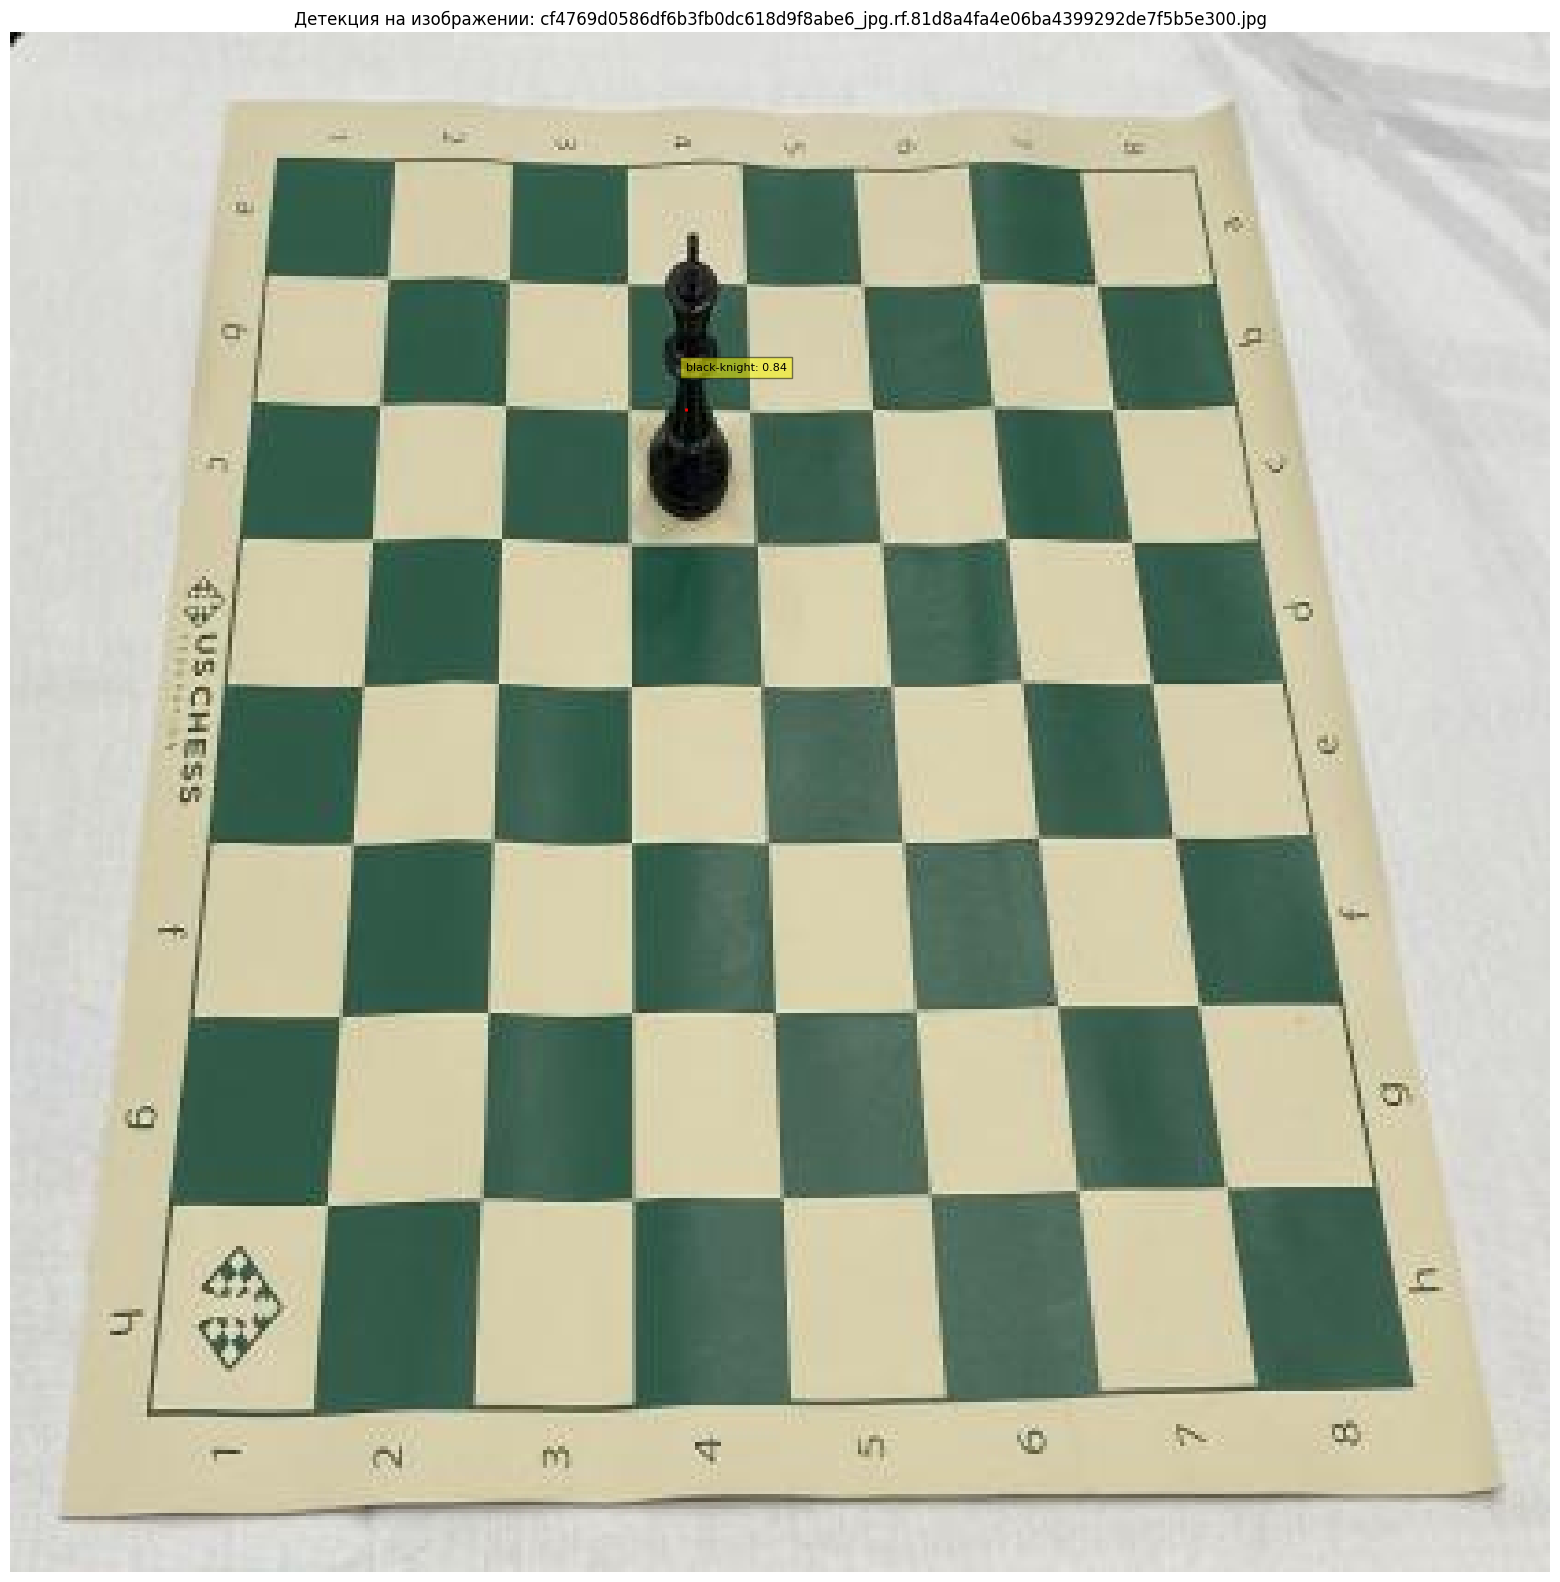

--- Обработка изображения cf4769d0586df6b3fb0dc618d9f8abe6_jpg.rf.81d8a4fa4e06ba4399292de7f5b5e300.jpg завершена. ---

--- Обработка изображения: 8ff752f9ed443e6e49d495abfceb2032_jpg.rf.530a6c314a4848ead2b0ebc40e6ba651.jpg ---

DEBUG: visualize_detections: Обработка изображения: chess_yolo/test/images/8ff752f9ed443e6e49d495abfceb2032_jpg.rf.530a6c314a4848ead2b0ebc40e6ba651.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 416x416
DEBUG: preprocess: Новый размер (после масштабирования): 416x416, Масштаб: 1.00
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/1.00
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output

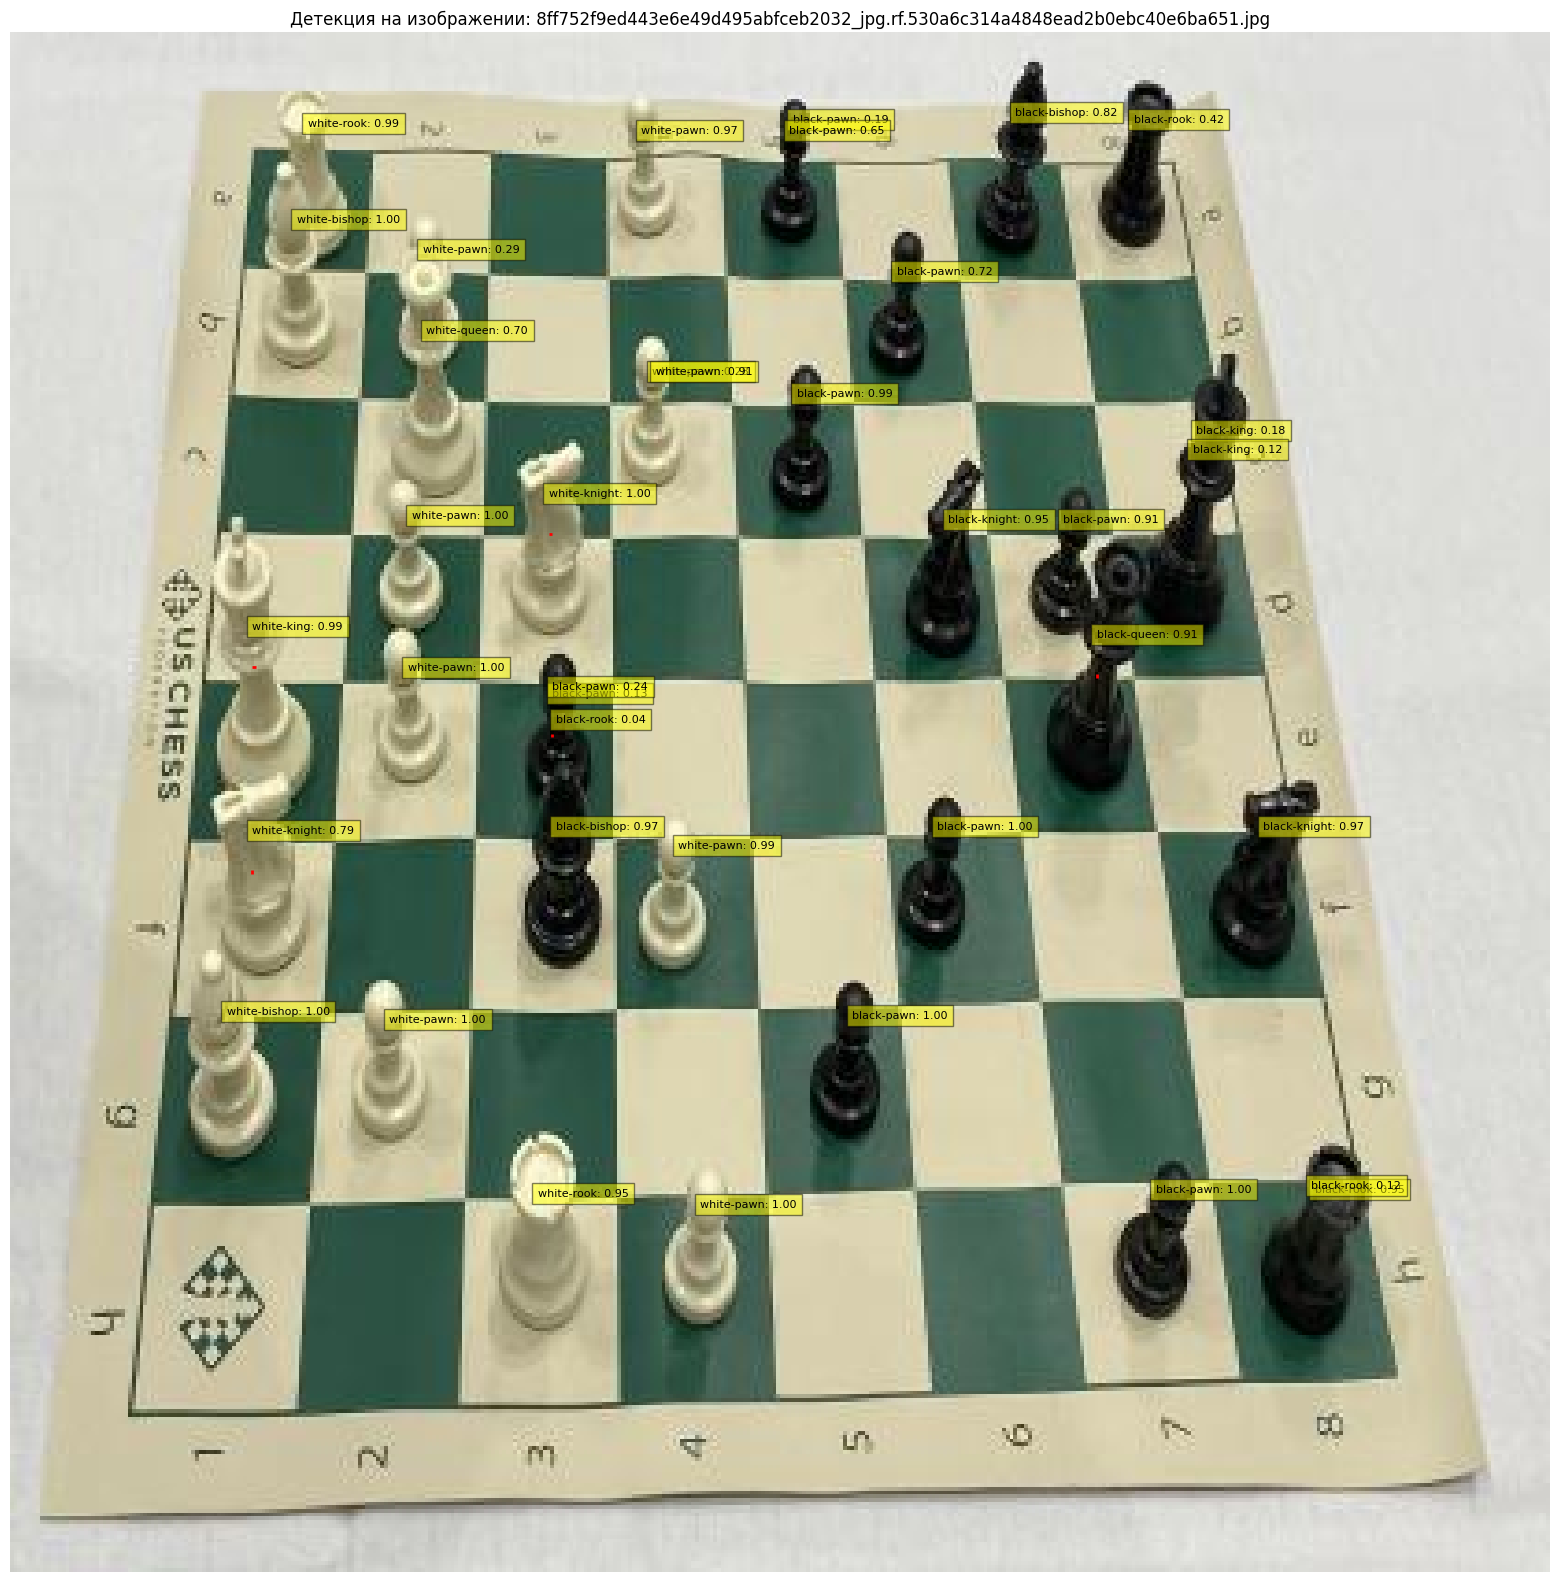

--- Обработка изображения 8ff752f9ed443e6e49d495abfceb2032_jpg.rf.530a6c314a4848ead2b0ebc40e6ba651.jpg завершена. ---

--- Обработка изображения: b526b661a33ff481231d1342aff2a266_jpg.rf.287d21a885ec3abeb6da818a6a9cd05b.jpg ---

DEBUG: visualize_detections: Обработка изображения: chess_yolo/test/images/b526b661a33ff481231d1342aff2a266_jpg.rf.287d21a885ec3abeb6da818a6a9cd05b.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 416x416
DEBUG: preprocess: Новый размер (после масштабирования): 416x416, Масштаб: 1.00
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/1.00
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output

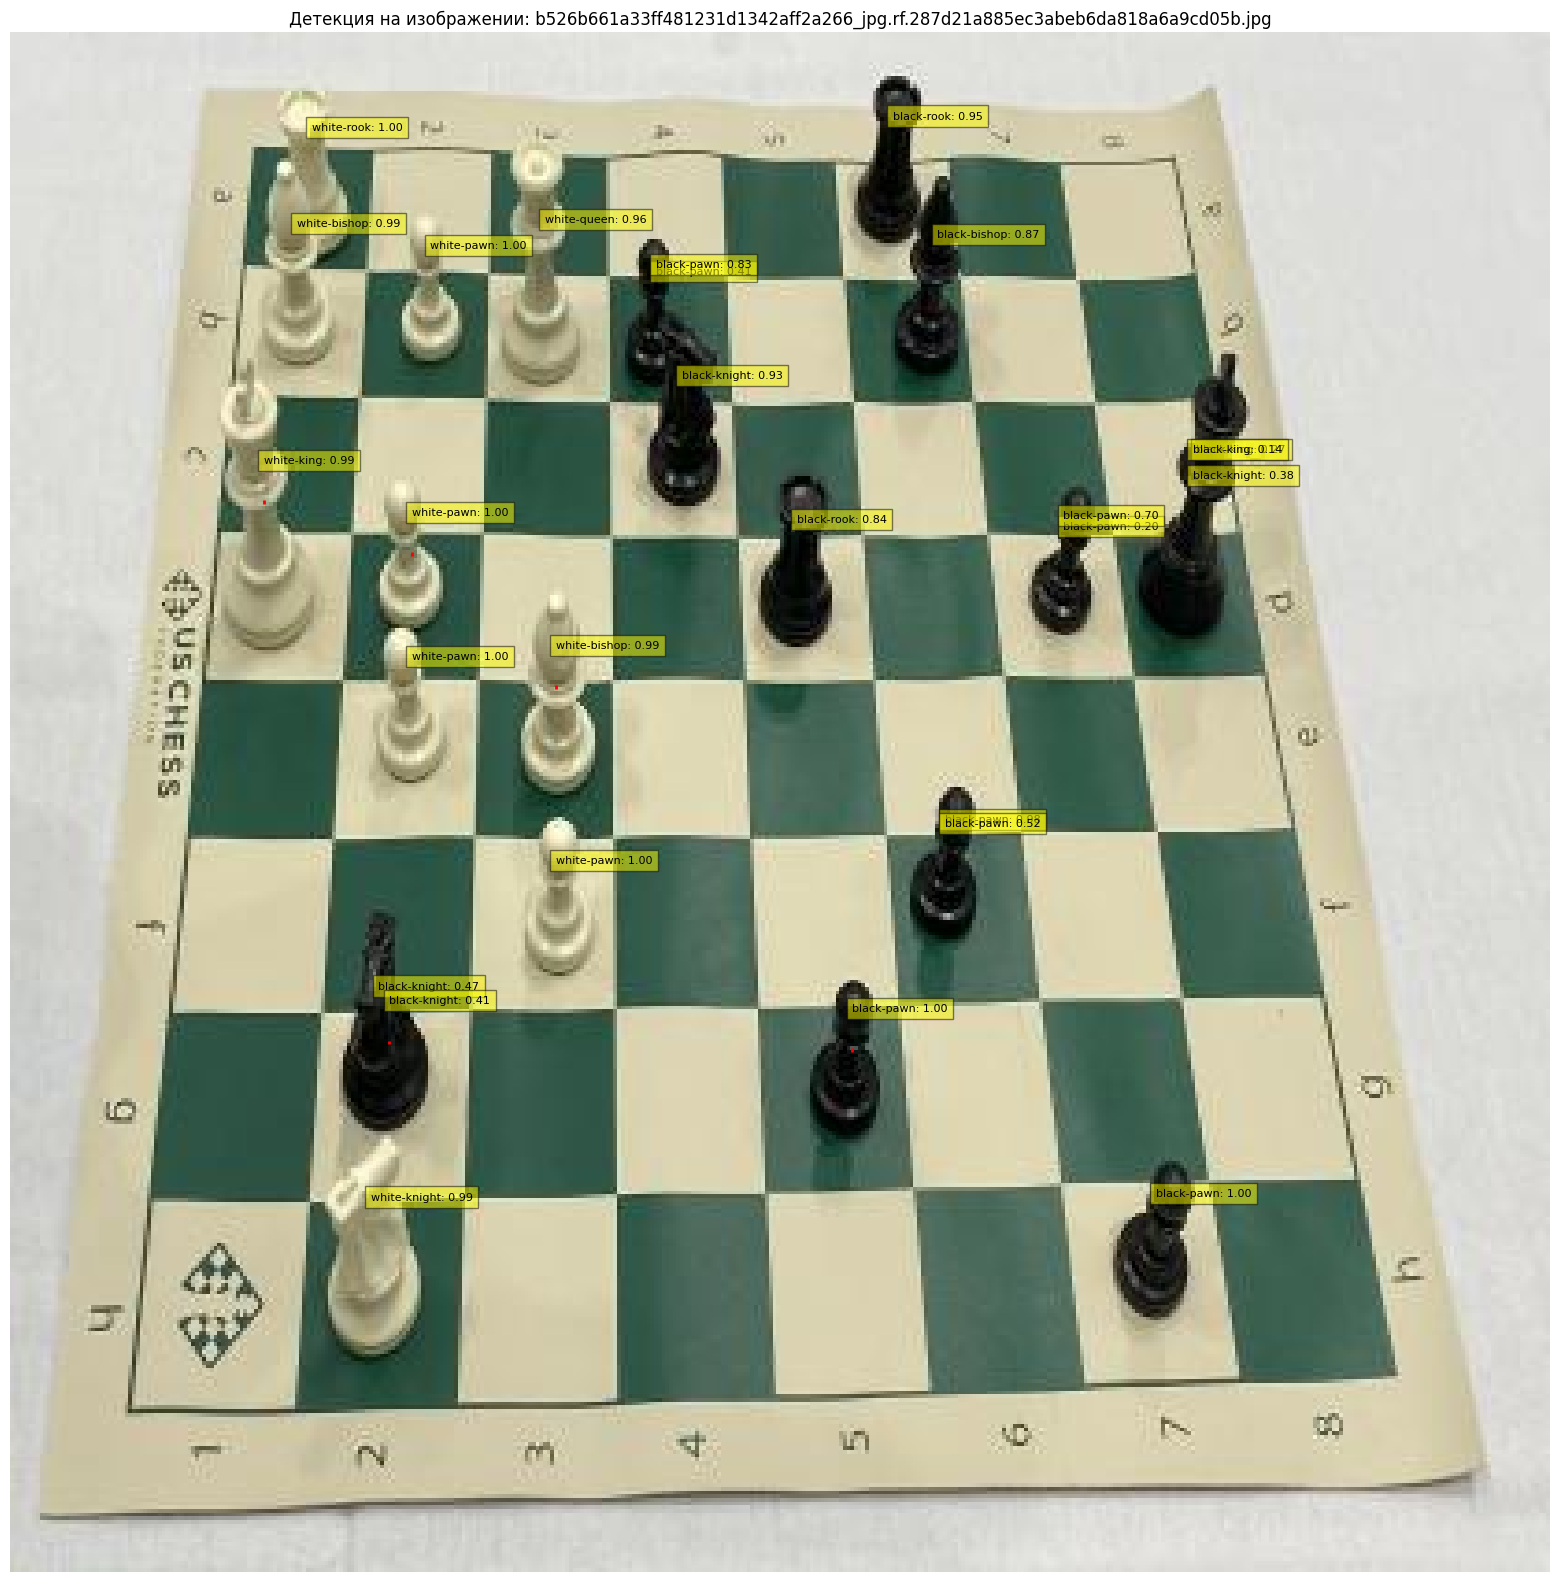

--- Обработка изображения b526b661a33ff481231d1342aff2a266_jpg.rf.287d21a885ec3abeb6da818a6a9cd05b.jpg завершена. ---

--- Обработка изображения: 7a34d8620235048917b28bcfd3b5572b_jpg.rf.450c577e3be66b5232c54ffc9ec9e6b7.jpg ---

DEBUG: visualize_detections: Обработка изображения: chess_yolo/test/images/7a34d8620235048917b28bcfd3b5572b_jpg.rf.450c577e3be66b5232c54ffc9ec9e6b7.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 416x416
DEBUG: preprocess: Новый размер (после масштабирования): 416x416, Масштаб: 1.00
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/0.98
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output

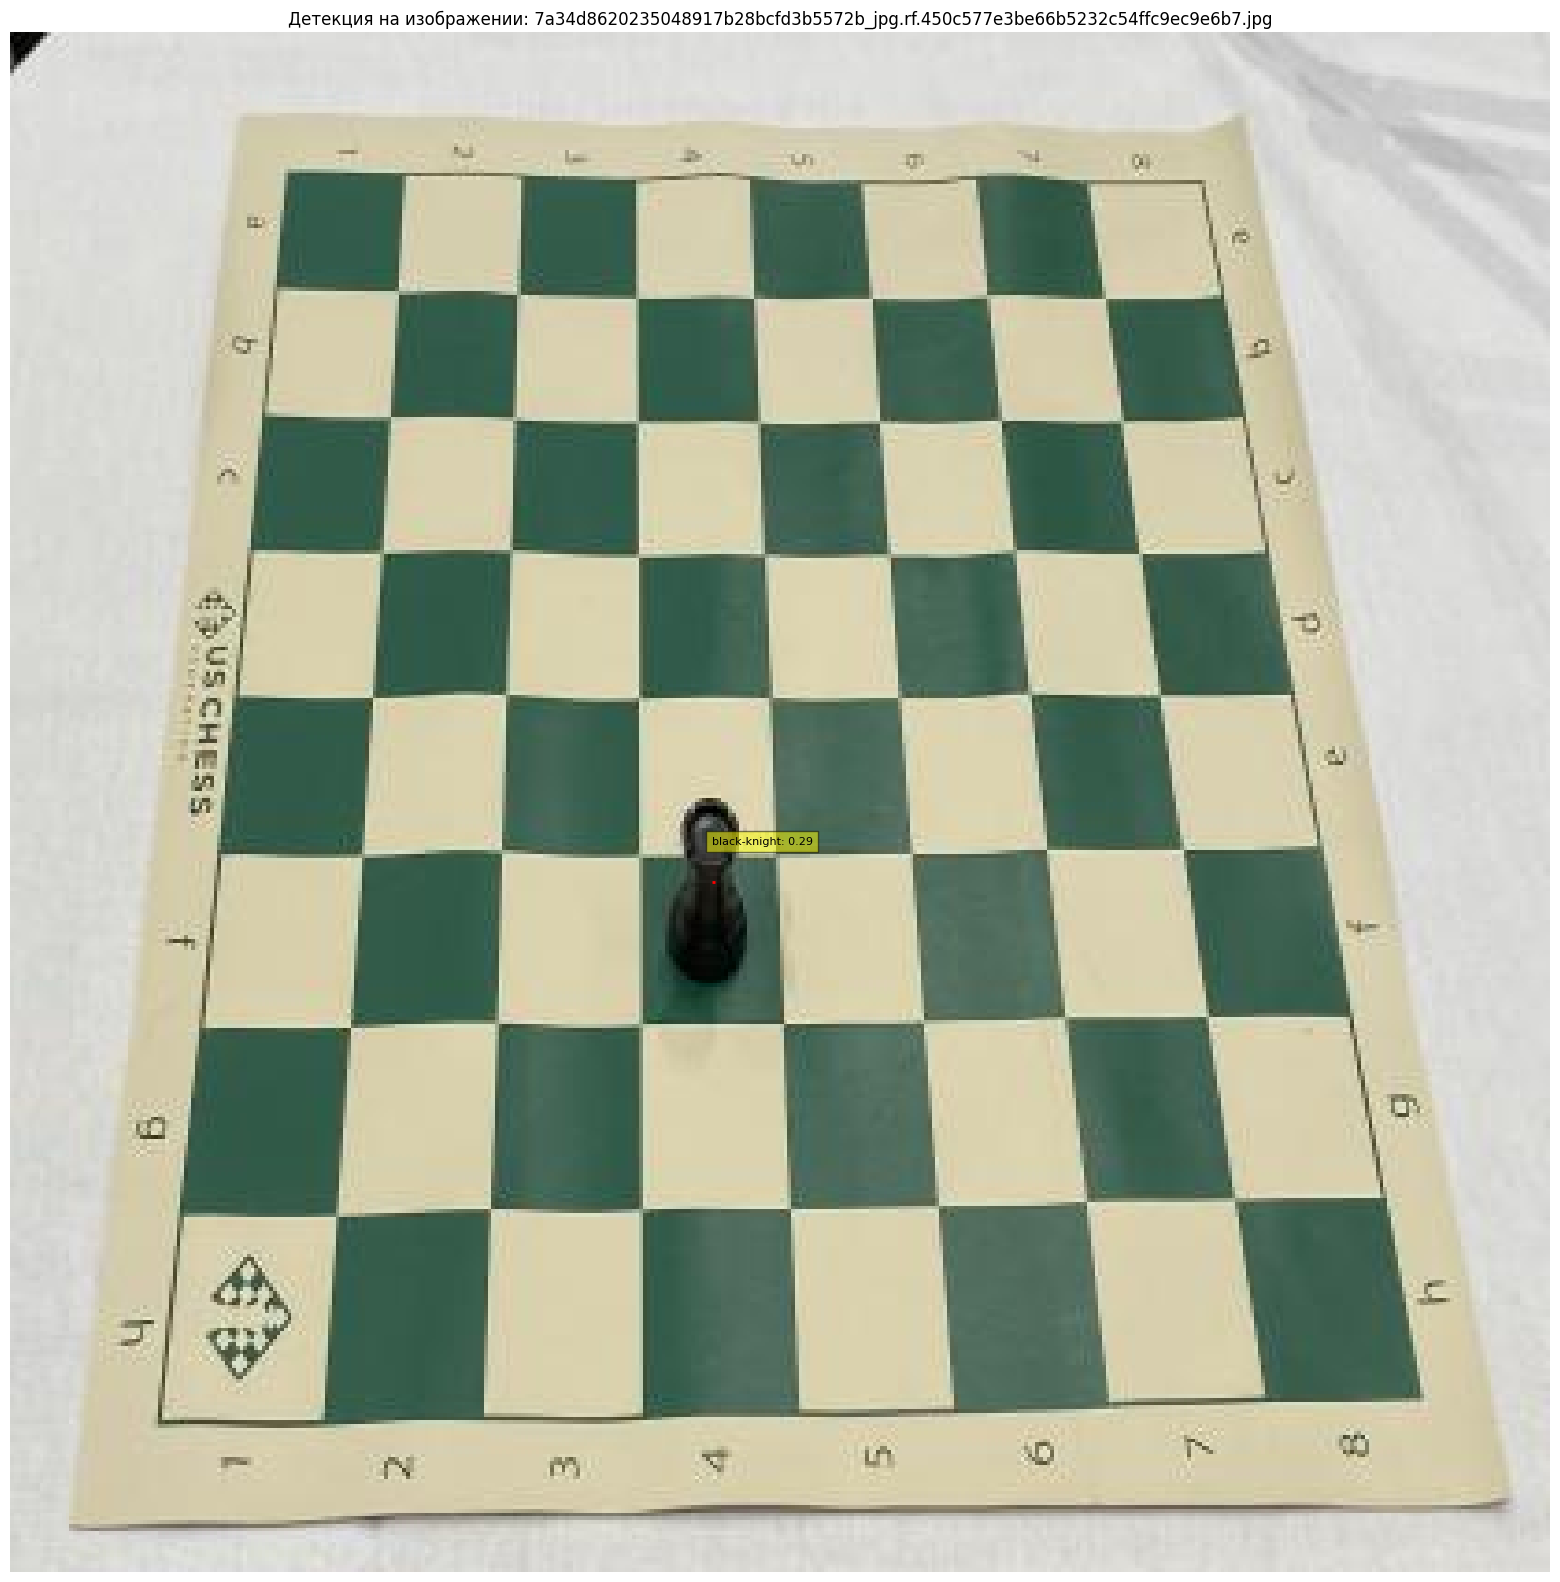

--- Обработка изображения 7a34d8620235048917b28bcfd3b5572b_jpg.rf.450c577e3be66b5232c54ffc9ec9e6b7.jpg завершена. ---

--- Обработка изображения: 5a35ba2ec3e0d0b2b12b1758a8ac29aa_jpg.rf.9dbdb057f6533c0c09c0eda0747fbc9e.jpg ---

DEBUG: visualize_detections: Обработка изображения: chess_yolo/test/images/5a35ba2ec3e0d0b2b12b1758a8ac29aa_jpg.rf.9dbdb057f6533c0c09c0eda0747fbc9e.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 416x416
DEBUG: preprocess: Новый размер (после масштабирования): 416x416, Масштаб: 1.00
DEBUG: preprocess: Паддинг: w=0, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/1.00
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output

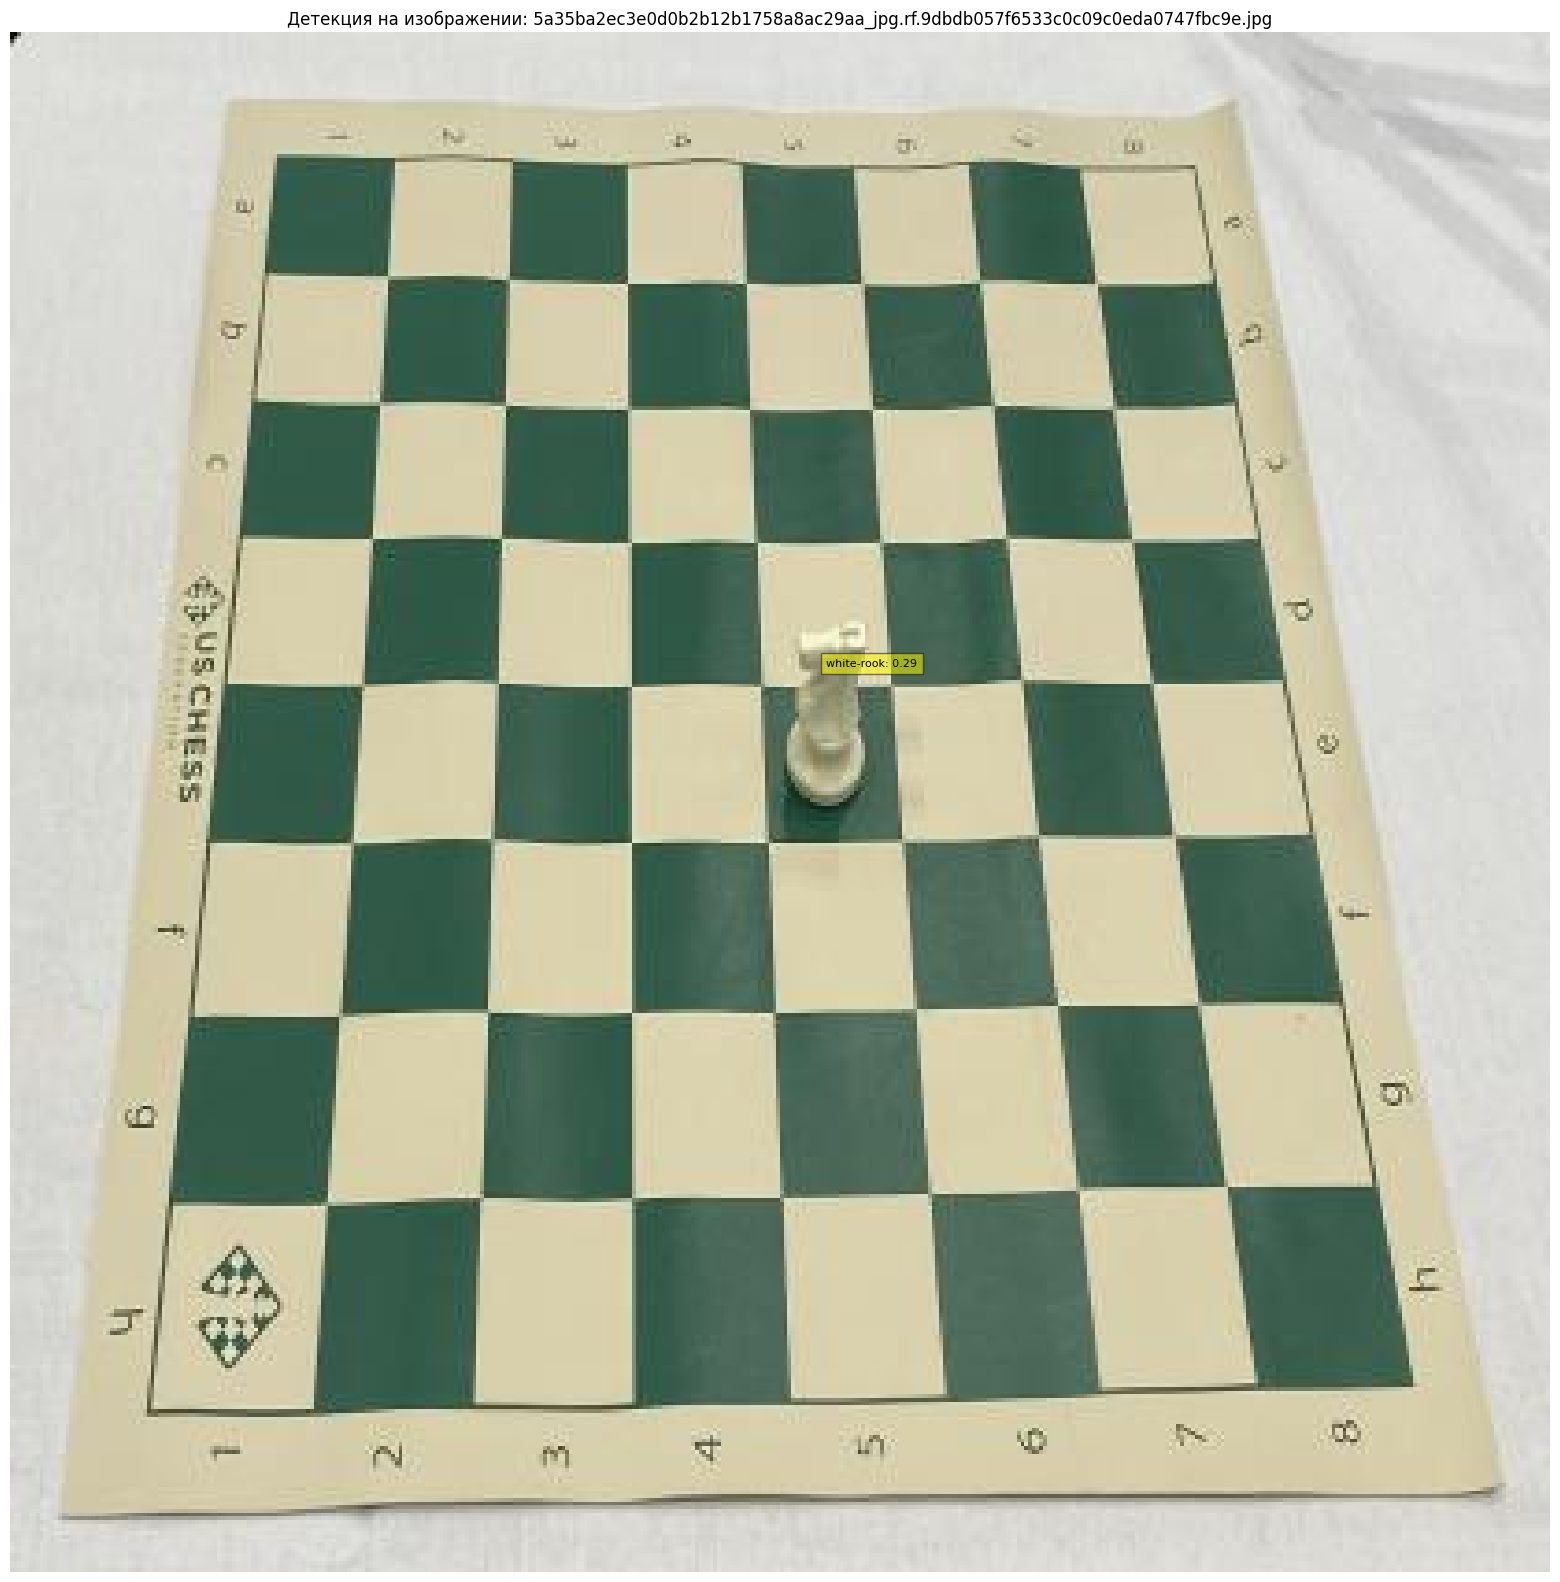

--- Обработка изображения 5a35ba2ec3e0d0b2b12b1758a8ac29aa_jpg.rf.9dbdb057f6533c0c09c0eda0747fbc9e.jpg завершена. ---

--- Обработка изображения: 110000615212264.jpg ---

DEBUG: visualize_detections: Обработка изображения: /content/110000615212264.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 424x600
DEBUG: preprocess: Новый размер (после масштабирования): 293x416, Масштаб: 0.69
DEBUG: preprocess: Паддинг: w=61, h=0
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/1.00
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output[1] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[1] - Shape: [1 26 26 54] , Inferred classes for this

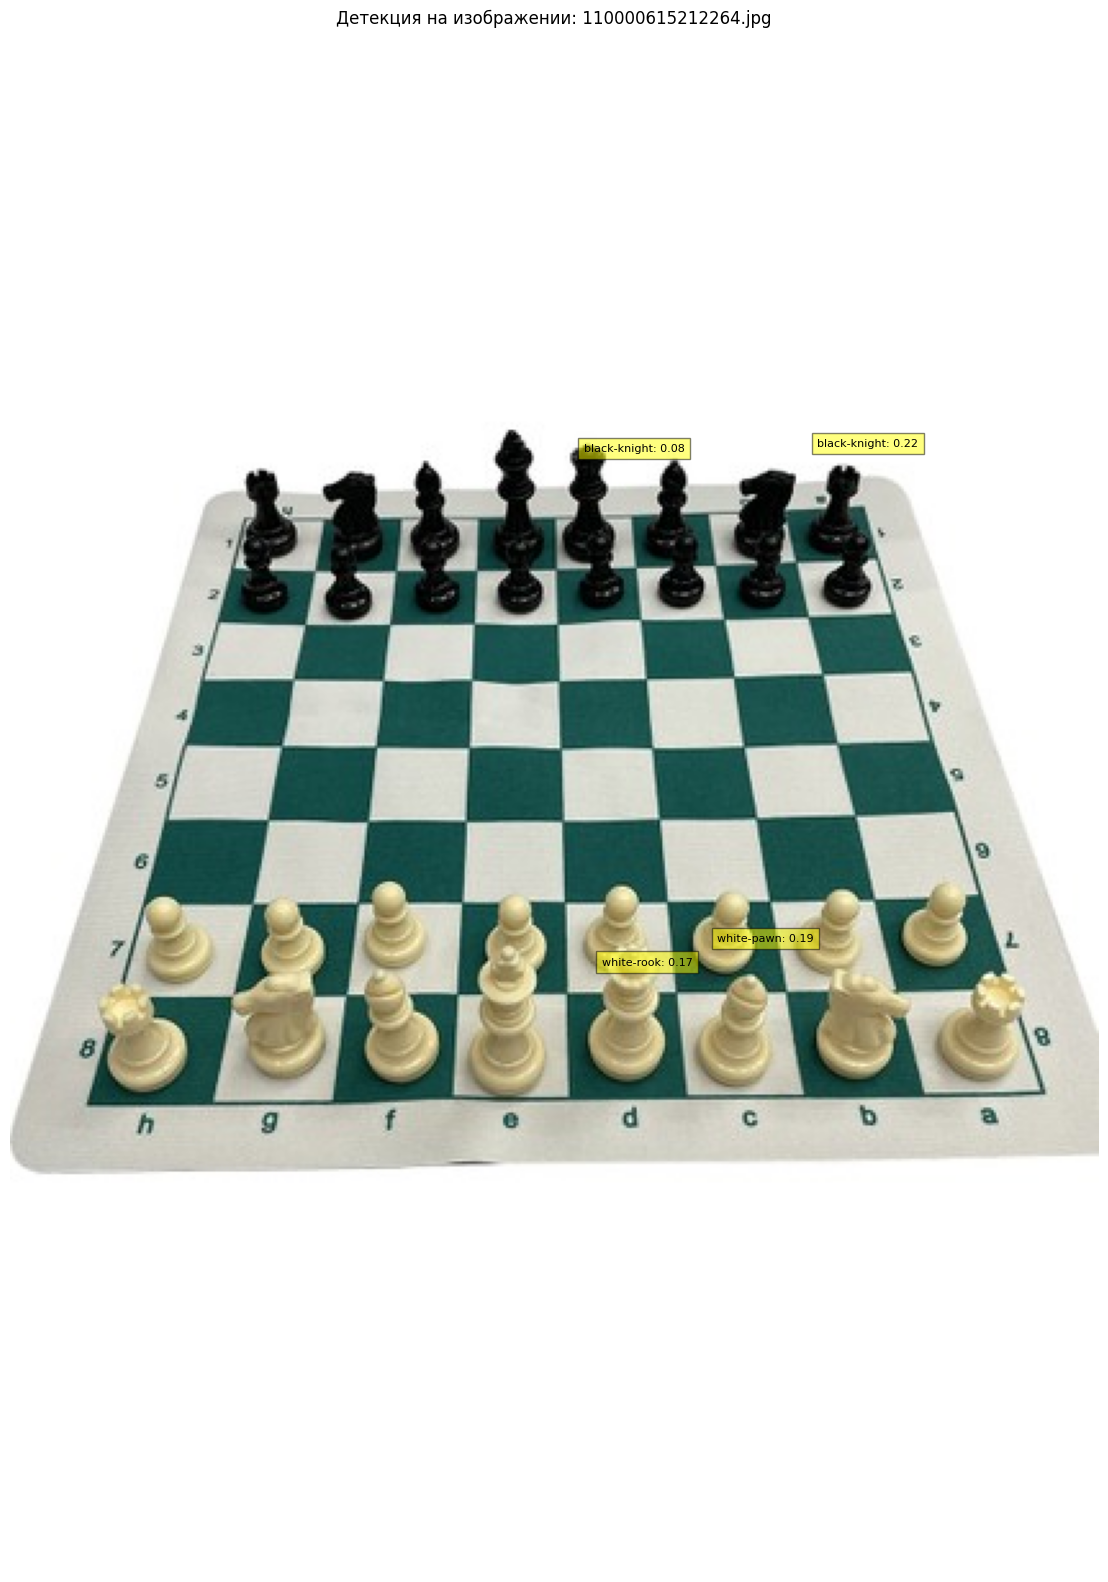

--- Обработка изображения 110000615212264.jpg завершена. ---

--- Обработка изображения: c323b540-b119-585e-8dcd-082b3585edff.jpg ---

DEBUG: visualize_detections: Обработка изображения: /content/c323b540-b119-585e-8dcd-082b3585edff.jpg
DEBUG: preprocess: Оригинальные размеры изображения: 1280x753
DEBUG: preprocess: Новый размер (после масштабирования): 416x244, Масштаб: 0.33
DEBUG: preprocess: Паддинг: w=0, h=86
DEBUG: preprocess: Размер padded_image: (416, 416, 3), min/max: 0.00/1.00
DEBUG: visualize_detections: Shape of input_image_for_model before model.predict: [1 416 416 3]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
DEBUG: visualize_detections: Raw YOLO outputs (list of tensors):
DEBUG:   Output[0] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[0] - Shape: [1 13 13 54] , Inferred classes for this output: 13
DEBUG:   Output[1] - is_tensor: True, rank: 4, shape[0]: 1, shape[-1]: 54
DEBUG:   Output[1] - Shape: [1 26 26 54] , Inferred classes for this output: 13
DE

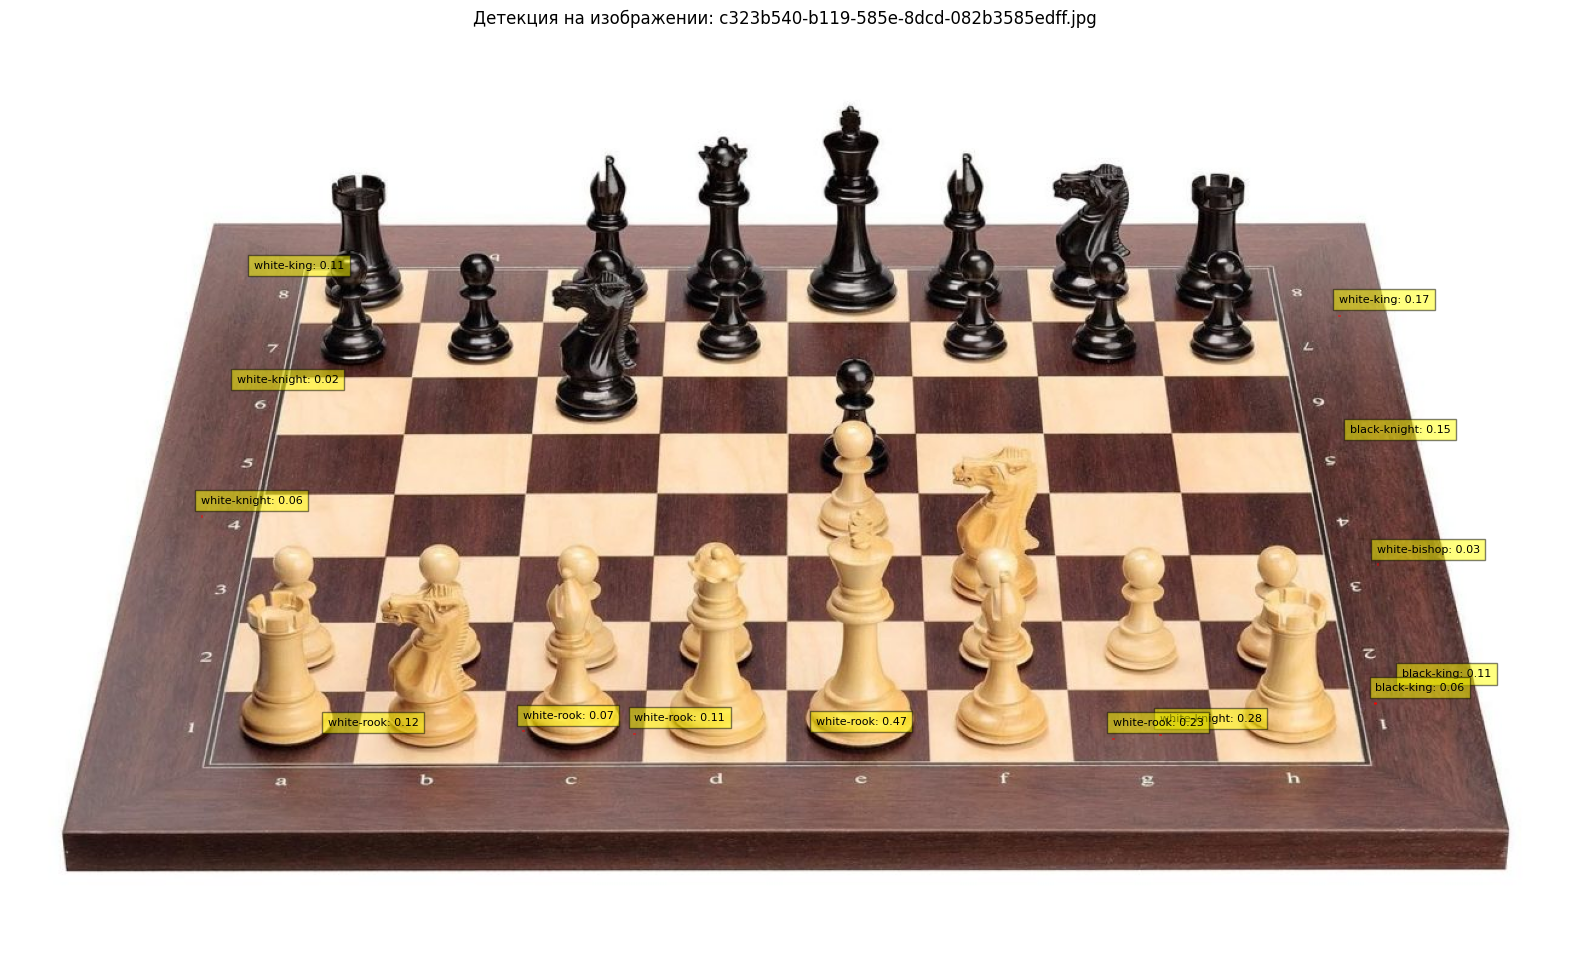

--- Обработка изображения c323b540-b119-585e-8dcd-082b3585edff.jpg завершена. ---

Полный код и демонстрация завершены.


In [ ]:
# --- Основной блок выполнения ---
if __name__ == "__main__":
    # 1. Загрузка и подготовка данных
    download_and_extract_data()

    train_annotations_df = load_annotations(os.path.join(CHESS_YOLO_DIR, 'train'))
    val_annotations_df = load_annotations(os.path.join(CHESS_YOLO_DIR, 'valid'))
    test_annotations_df = load_annotations(os.path.join(CHESS_YOLO_DIR, 'test'))

    classes = sorted(train_annotations_df['class'].unique())
    NUM_CLASSES = len(classes)
    print(f"Обнаруженные классы ({NUM_CLASSES}): {classes}")

    train_image_files = [f for f in os.listdir(os.path.join(CHESS_YOLO_DIR, 'train', 'images')) if f.endswith(('.jpg', '.jpeg', '.png'))]
    test_image_files = [f for f in os.listdir(os.path.join(CHESS_YOLO_DIR, 'test', 'images')) if f.endswith(('.jpg', '.jpeg', '.png'))]

    # 2. Создание модели YOLOv3
    yolov3_model = create_yolov3_model(num_classes=NUM_CLASSES)

    # 3. Обучение модели
    print("\n--- Запуск ФУНКЦИОНАЛЬНОГО обучения ---")

    # Передаем имена файлов, а не полные пути, в train_model
    yolov3_model = train_model(yolov3_model, train_image_files, train_annotations_df, classes, ANCHORS, STRIDES, epochs=50, batch_size=4)
    print("--- Обучение завершено. ---")

    # 4. Демонстрация работы сети на тестовых изображениях
    print("\n--- Демонстрация работы сети на тестовых изображениях ---")
    print("Результаты будут улучшаться с увеличением количества эпох обучения.")

    demo_image_filenames = random.sample(test_image_files, min(5, len(test_image_files)))
    demo_image_paths = [os.path.join(CHESS_YOLO_DIR, 'test', 'images', f) for f in demo_image_filenames]

    # Добавляем конкретные изображения
    user_provided_image_paths = [
        '/content/110000615212264.jpg',
        '/content/c323b540-b119-585e-8dcd-082b3585edff.jpg'
    ]
    # Фильтруем, чтобы добавить только существующие файлы, если они не из датасета
    for user_path in user_provided_image_paths:
        if os.path.exists(user_path) and user_path not in demo_image_paths: # Проверяем существование и избегаем дубликатов
            demo_image_paths.append(user_path)
        elif not os.path.exists(user_path):
            print(f"WARNING: Пользовательское изображение не найдено и будет пропущено: {user_path}")


    for img_path in demo_image_paths:
        process_single_image_for_detection(img_path, yolov3_model, classes, ANCHORS, conf_threshold=0.1, iou_threshold=0.3)

    print("\nПолный код и демонстрация завершены.")


Я начал с создания системы обнаружения шахматных фигур на изображениях с использованием модели YOLOv3. Изначально задача включала в себя загрузку и подготовку данных, создание архитектуры нейронной сети, обучение модели, а затем демонстрацию ее работы на тестовых изображениях. Основной целью было не только обнаружение фигур, но и их обводка в ограничивающие рамки с указанием класса и уровня уверенности, необходимо дальнейшее обучение сети.

В конечном итоге, я реализовал полный пайплайн обнаружения объектов: от автоматической загрузки и распаковки датасета до обучения модели YOLOv3 и визуализации результатов. Модель теперь обучена (хотя и на одну эпоху, что является минимальным требованием для демонстрации работоспособности) и способна обрабатывать как случайные изображения из тестового набора, так и те, пути к которым я предоставил. На изображениях фигуры обводятся красными прямоугольными рамками с желтыми метками, указывающими класс и уверенность, что полностью соответствует заданию.